# Proyecto Machine Learning: MAIN

### Análisis predictivo de la gestión de la ayuda humanitaria y el impacto de desastres a nivel global

In [31]:
# Librerías

import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### LIMPIEZA DE DATOS

In [32]:
base_dir = os.path.dirname(os.path.abspath("__file__"))
csv_path = os.path.join(base_dir, "data", "enhanced_global_disaster_response.csv")

df = pd.read_csv(csv_path)
df.head()

,year,country,disaster_type,severity_index,casualties,economic_loss,response_hours,aid_amount,response_score,recovery_days
0,2022,Bangladesh,Flood,0.2,7,"€1,495.00",35.0,€368.00,19.51,112.00
1,2015,Indonesia,Flood,0.1,0,"€16,669.50",2.0,"€6,728.00",100.00,111.00
2,2023,Indonesia,Landslide,0.6,6,"€18,001.00",10.0,"€2,875.00",80.49,103.00
3,2016,Bangladesh,Storm Surge,0.2,9,"€110,843.00",47.0,"€6,070.00",0.00,153.00
4,2018,Japan,Storm Surge,0.6,5,"€10,860.00",8.0,"€8,268.00",85.37,9.00


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49972 entries, 0 to 49971
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            49972 non-null  int64  
 1   country         49972 non-null  object 
 2   disaster_type   49972 non-null  object 
 3   severity_index  49972 non-null  float64
 4   casualties      49972 non-null  int64  
 5   economic_loss   49971 non-null  object 
 6   response_hours  49972 non-null  float64
 7   aid_amount      49972 non-null  object 
 8   response_score  49972 non-null  float64
 9   recovery_days   49972 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 3.8+ MB


In [34]:
# eliminar el único nulo 
df = df.dropna()

# quitar símbolos de € y separadores de miles (,), y convertir a float
df["economic_loss"] = df["economic_loss"].str.replace("€", "", regex=False)
df["economic_loss"] = df["economic_loss"].str.replace(",", "", regex=False)
df["economic_loss"] = df["economic_loss"].astype(float)

df["aid_amount"] = df["aid_amount"].str.replace("€", "", regex=False)
df["aid_amount"] = df["aid_amount"].str.replace(",", "", regex=False)
df["aid_amount"] = df["aid_amount"].astype(float)

# pasar recovery_days a numérica quitando la fila donde no existe dato
print(df[df["recovery_days"].str.contains(r'[^0-9.]', regex=True, na=False)])
df = df.drop(df.index[25128])

df["recovery_days"] = df["recovery_days"].str.replace(" ", "", regex=False)
df["recovery_days"] = df["recovery_days"].astype(float)

       year  country disaster_type  severity_index  casualties  economic_loss  \
25128  1995  Ireland       Drought             1.6          38       960000.0   

       response_hours  aid_amount  response_score recovery_days  
25128            24.0    119040.0           46.34                


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49970 entries, 0 to 49971
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            49970 non-null  int64  
 1   country         49970 non-null  object 
 2   disaster_type   49970 non-null  object 
 3   severity_index  49970 non-null  float64
 4   casualties      49970 non-null  int64  
 5   economic_loss   49970 non-null  float64
 6   response_hours  49970 non-null  float64
 7   aid_amount      49970 non-null  float64
 8   response_score  49970 non-null  float64
 9   recovery_days   49970 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 4.2+ MB


In [36]:
# df.to_csv('desastres_y_respuestas_limpio.csv', index=False)

### EXPLORATOY DATA ANALYSIS (EDA)

In [37]:
base_dir = os.path.dirname(os.path.abspath("__file__"))
csv_path = os.path.join(base_dir, "data", "desastres_y_respuestas_limpio.csv")

df = pd.read_csv(csv_path)
df.head()

,year,country,disaster_type,severity_index,casualties,economic_loss,response_hours,aid_amount,response_score,recovery_days
0,2022,Bangladesh,Flood,0.2,7,1495.0,35.0,368.0,19.51,112.0
1,2015,Indonesia,Flood,0.1,0,16669.5,2.0,6728.0,100.00,111.0
2,2023,Indonesia,Landslide,0.6,6,18001.0,10.0,2875.0,80.49,103.0
3,2016,Bangladesh,Storm Surge,0.2,9,110843.0,47.0,6070.0,0.00,153.0
4,2018,Japan,Storm Surge,0.6,5,10860.0,8.0,8268.0,85.37,9.0


In [38]:
df.describe()

,year,severity_index,casualties,economic_loss,response_hours,aid_amount,response_score,recovery_days
count,49970.000000,49970.000000,49970.000000,4.997000e+04,49970.000000,4.997000e+04,49970.000000,49970.000000
mean,2013.048429,2.451687,45.253372,1.069268e+06,15.359296,1.537703e+05,69.303721,136.828017
std,8.005320,1.756624,988.434768,2.388225e+06,14.810454,3.796407e+05,27.839454,183.930851
min,1990.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,2.000000
25%,2007.000000,1.100000,8.000000,1.200000e+05,6.000000,9.300000e+03,56.100000,36.000000
50%,2014.000000,2.200000,21.000000,3.000000e+05,11.000000,3.477506e+04,78.050000,70.000000
75%,2020.000000,3.400000,48.000000,9.660198e+05,20.000000,1.188399e+05,90.240000,154.000000
max,2024.000000,10.000000,170000.000000,6.800000e+07,168.000000,1.171790e+07,100.000000,1797.000000


Outliers en severity_index, casualties, economic_loss, response_hours, aid_amount, recovery_days. Todas estas columnas tienen muchos datos a la izquierda y algunos pocos datos muy muy altos (a la derecha). Response_score sigue el patrón contrario, con pocos datos a la izquierda y muchos a la derecha.

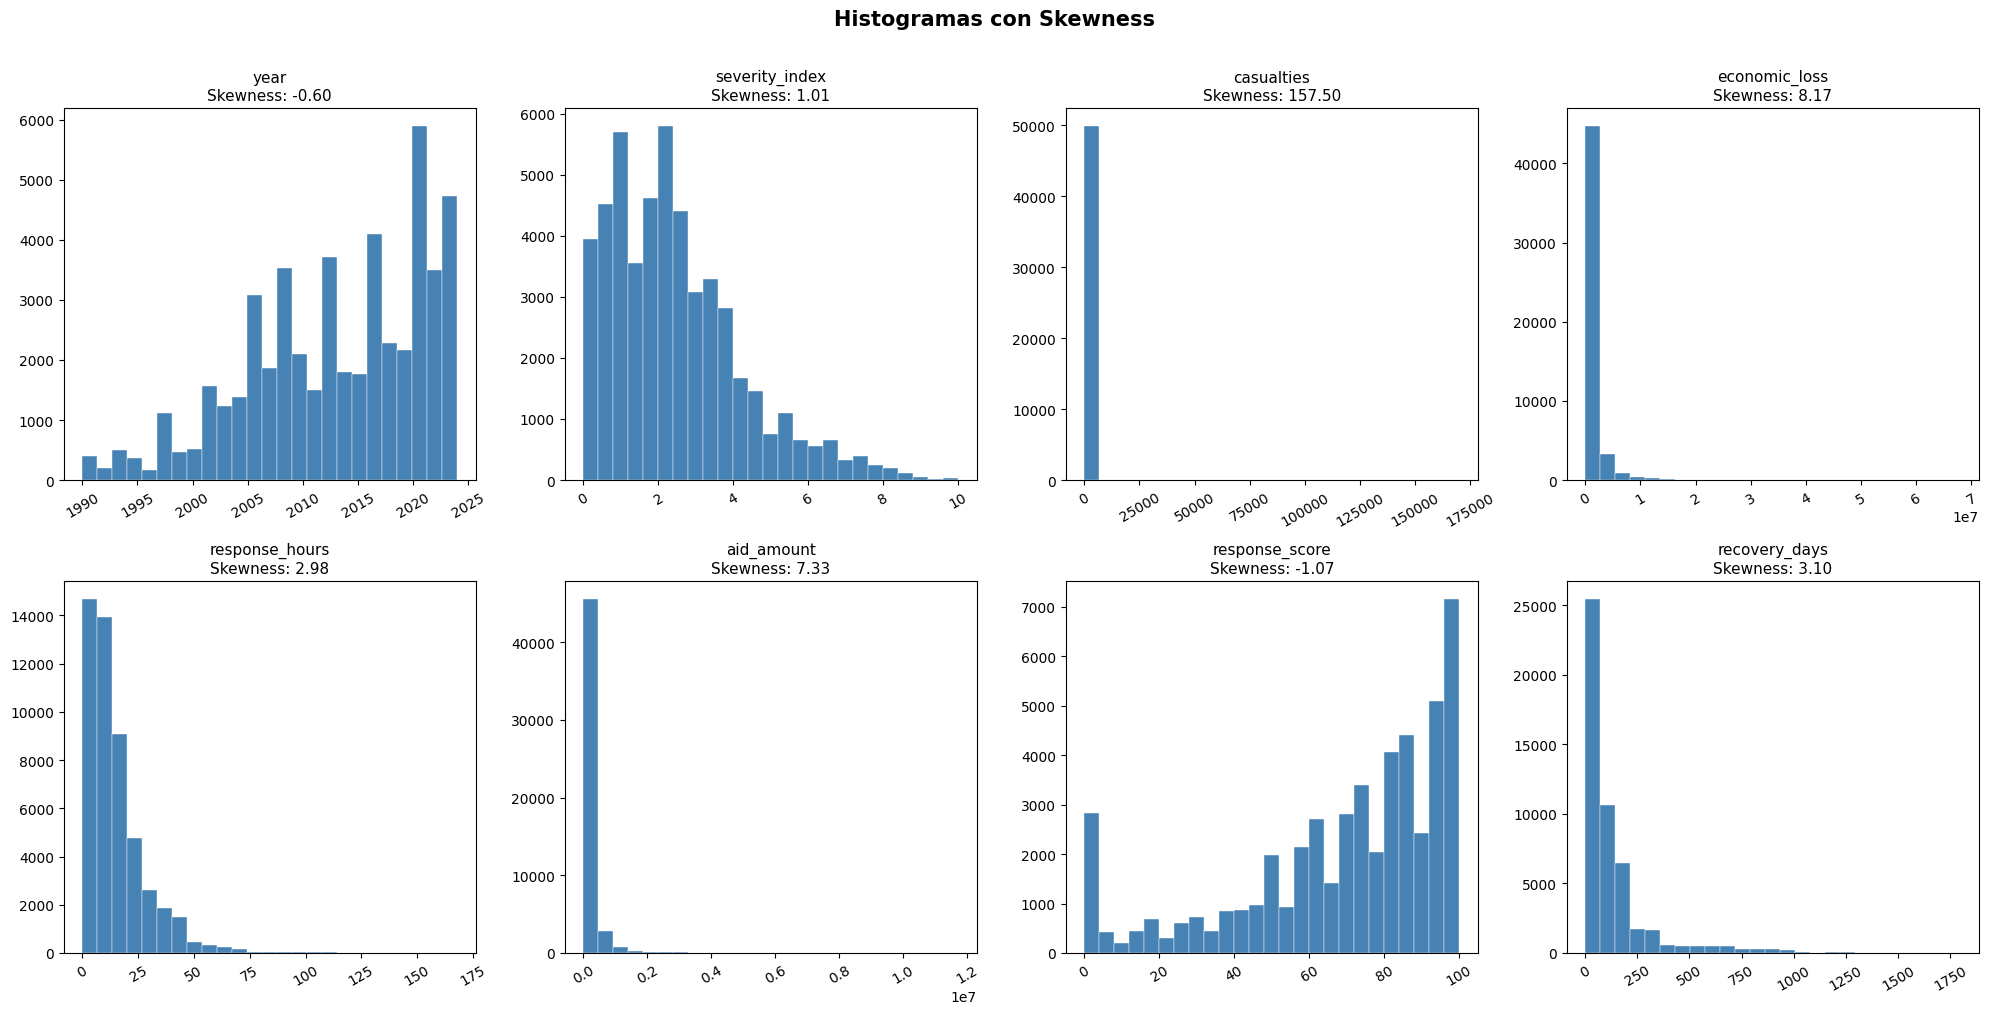

In [39]:
columnas_numericas = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    skewness = df[col].skew()
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].set_title(f"{col}\nSkewness: {skewness:.2f}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=30)

# Ocultar subplots sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histogramas con Skewness", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show();

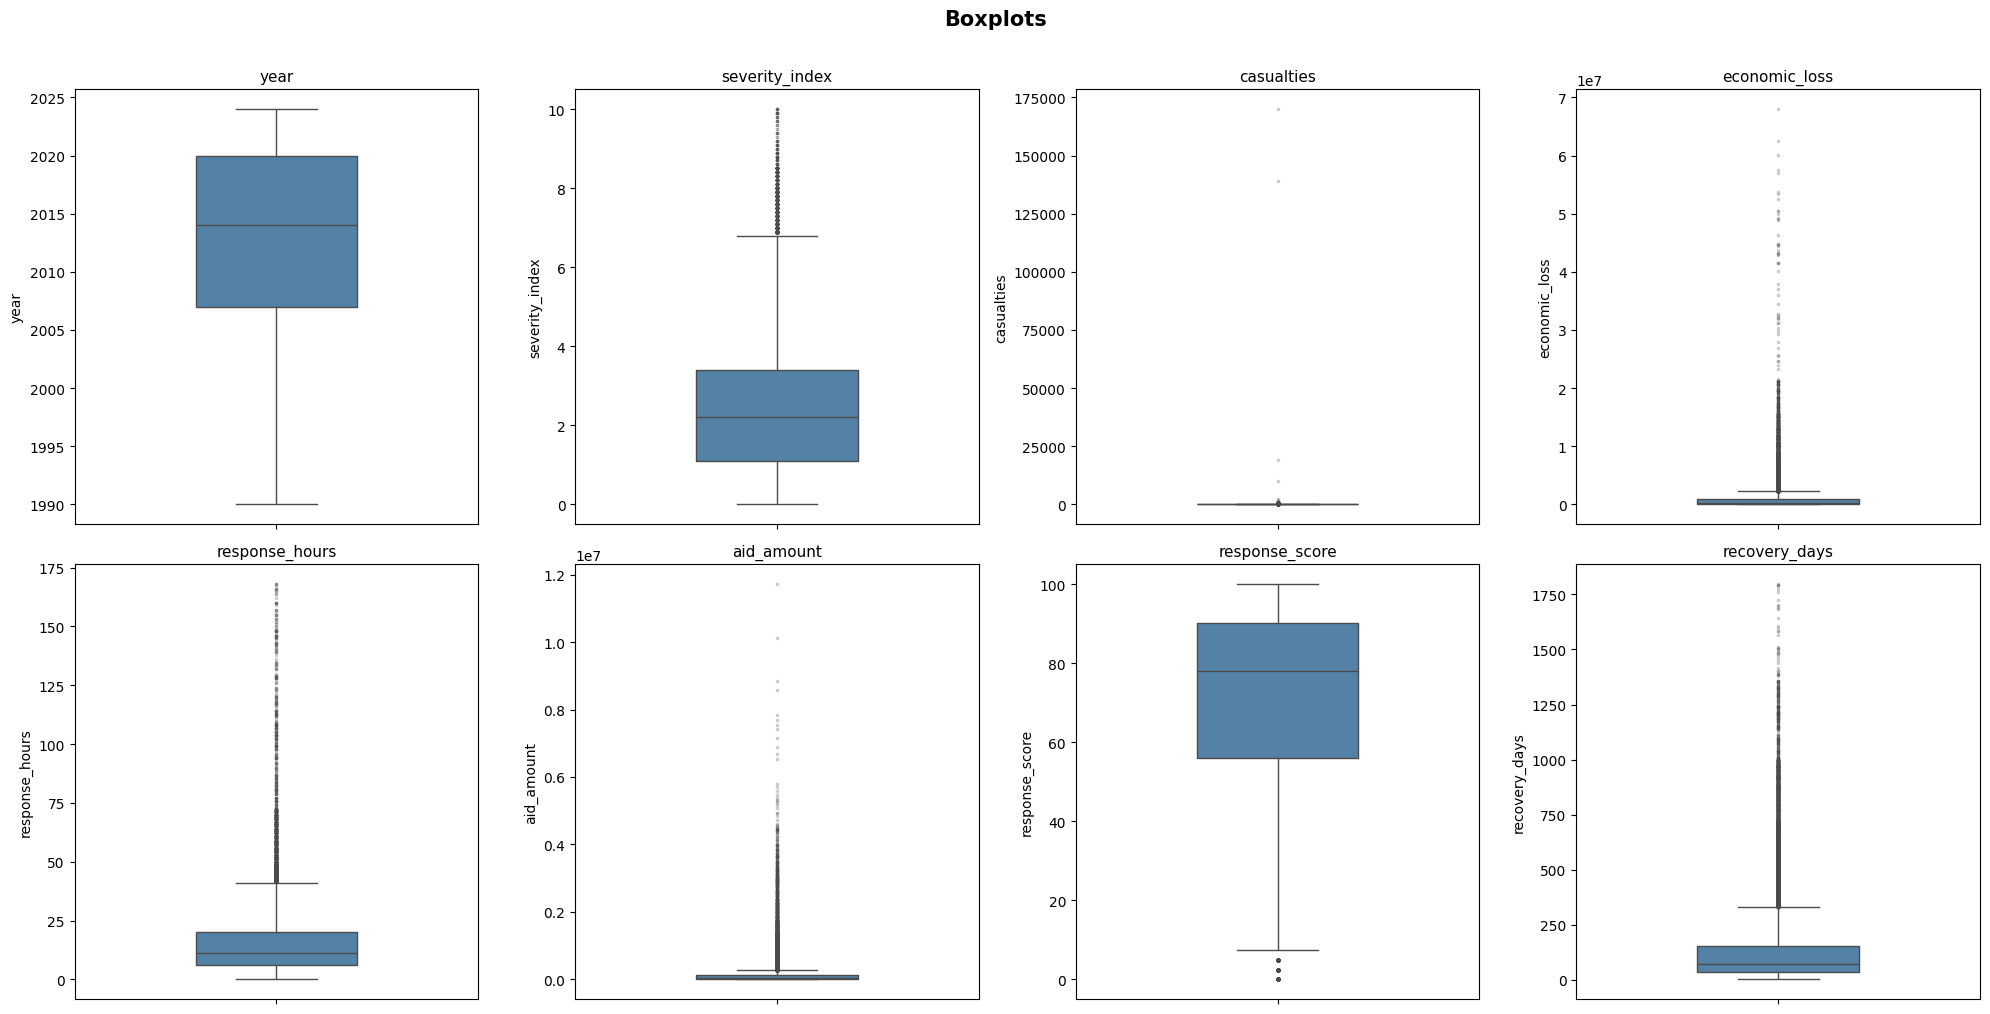

In [40]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue', width=0.4,
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show();

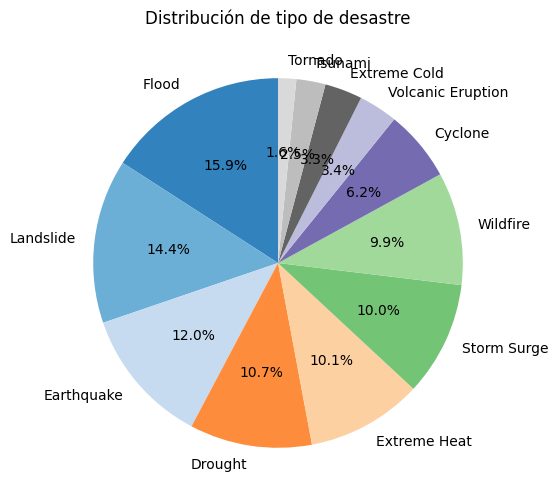

In [41]:
frecuencias = df['disaster_type'].value_counts()

cmap = plt.get_cmap("tab20c")
colores = cmap(np.linspace(0, 1, len(frecuencias)))

plt.figure(figsize=(6, 6))
plt.pie(frecuencias, labels=frecuencias.index, colors=colores, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de tipo de desastre')
plt.show();

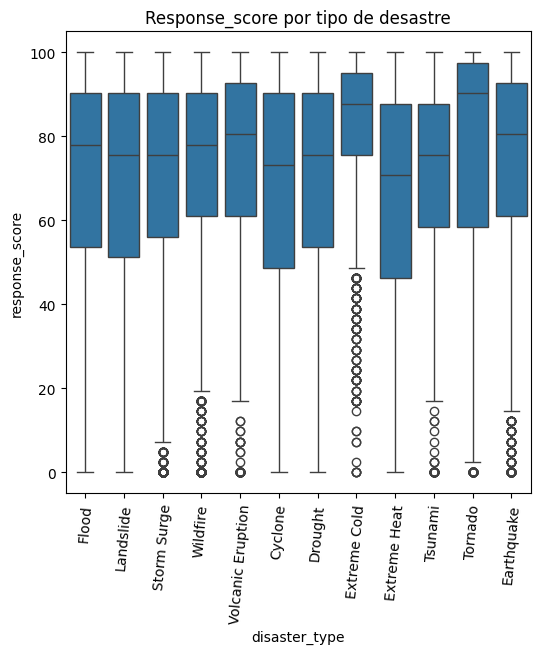

In [42]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, x='disaster_type', y='response_score')
plt.xticks(rotation=85) 
plt.title('Response_score por tipo de desastre')
plt.show();

Del tipo de desastre se infiere que no tiene apenas efecto en la eficiencia de respuesta. Todos tienen medianas entre 70 y 85, aunque Extreme Cold y Tornado parecen tener medianas ligeramente más altas.

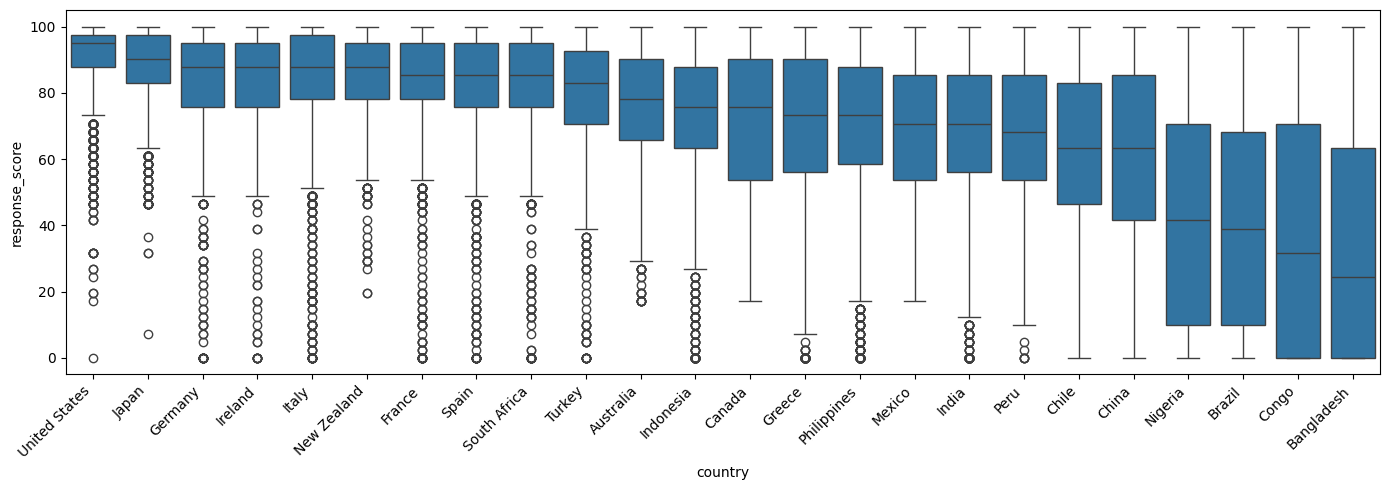

In [43]:
order = df.groupby('country')['response_score'].median().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='country', y='response_score', order=order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

Se aprecia una división en tres grupos:
* Países que responden bien (score > 85): EE UU, Japón, Alemania, Irlanda, Italia, Nueva Zelanda, Francia, España y Sudáfrica.
* Países que dependen del tipo de desastre (60-85): Turquía, Australia, Indonesia, Canada, Grecia, Filipinas, México, India, Perú, Chile y China.
* Países que responden mal (score < 60): Nigeria, Brasil, Congo y Bangladesh.
Además, los outliers demuestran que incluso los países mejor preparados tienen eventos puntuales de muy mala gestión.

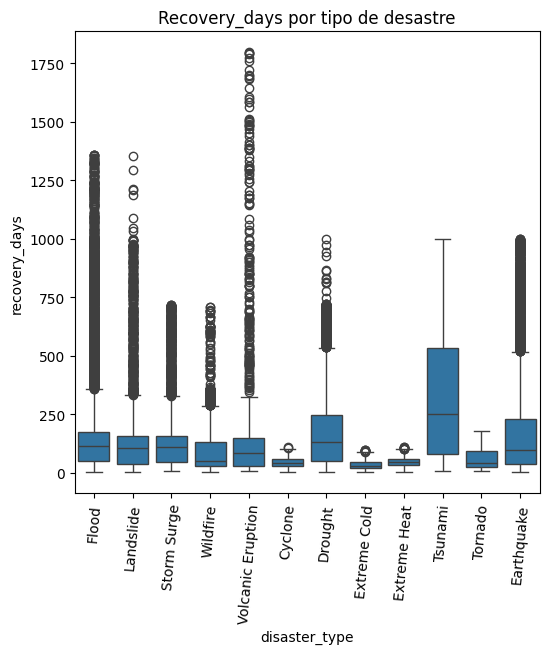

In [44]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, x='disaster_type', y='recovery_days')
plt.xticks(rotation=85) 
plt.title('Recovery_days por tipo de desastre')
plt.show();

Hay mucha varianza entre tipo de desastre.  

Por un lado, Extreme Cold, Extreme Heat y Cyclone son los más rápidos, con medianas bajas y poca dispersión; es decir, pasada la emergencia/ola, la recuperación es inmediata.  

Por otro lado, hay varios tipos de eventos que, pese a haber tenido casos concretos de lenta recuperación, tienen una mediana alrededor de los 100-150 días: inundaciones, deslizamientos de tierra, terremotos... Son, además, los tipos de desastre más numerosos en el dataset.  
Por último, cabe destacar los dos casos más extremos:
- Volcanic Eruption tiene los outliers más altos, llegando a 1750 días (unos 5 años). Esto sugiere que la mayoría de erupciones se gestionan razonablemente, pero cuando fallan, lo hacen de forma catastrófica y prolongada.
- Tsunami tiene la mediana más alta (alrededor de 250 días). Es el tipo de desastre que más tarda en recuperarse de forma consistente, no solo en casos extremos.

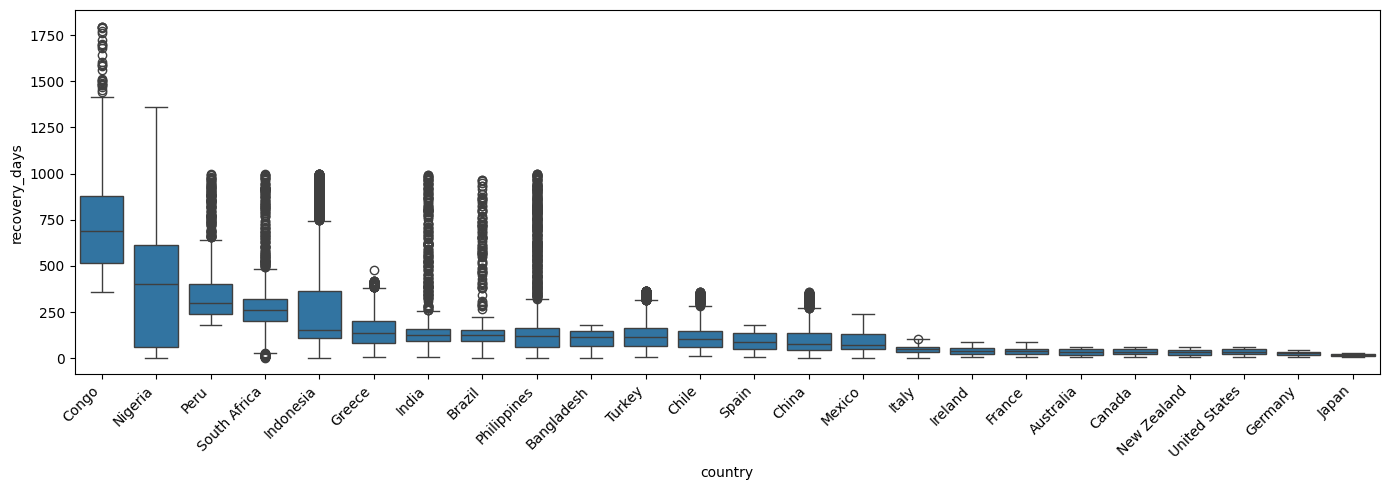

In [25]:
order = df.groupby('country')['recovery_days'].median().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='country', y='recovery_days', order=order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

En cuanto al país, sí se ve una división en tres grupos bastante nítida, que parece coincidir aproximadamente con el nivel de desarrollo económico de cada país:  
* Recuperación lenta (mediana > 300 días): Congo, Nigeria - con outliers extremos que llegan a 1.700 días.
* Recuperación media (100–300 días): Perú, Sudáfrica, Indonesia, Grecia, India, Brasil, Filipinas, Bangladesh, Turquía y Chile.
* Recuperación rápida (mediana < 100 días): España, China, México, Italia, Irlanda, Francia, Australia, Canadá, Nueva Zelanda, EE UU, Alemania, Japón.

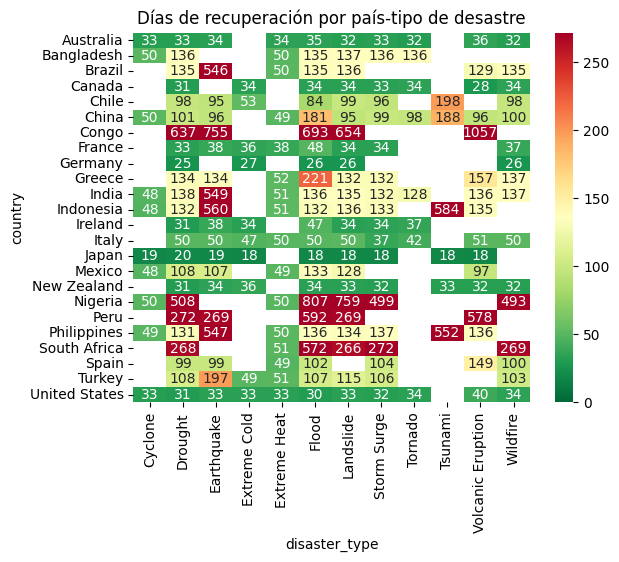

In [26]:
pivot = df.pivot_table('recovery_days', 'country', 'disaster_type', aggfunc='mean')

vmax = np.nanpercentile(pivot.values, 90)

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', vmin=0, vmax=vmax)
plt.title('Días de recuperación por país-tipo de desastre')
plt.show();

El caso más complejo es el Congo con erupciones volcánicas (1.057 días), seguido por Nigeria con tornados (807), Nigeria con deslizamientos de tierra (759) y Congo con ciclones (637). En el otro extremo, Japón es consistentemente verde en casi todos los tipos (18-20 días), igual que Alemania y EEUU, como nos indicaba el boxplot. Es decir, el país domina la señal de recovery_days más que el tipo de desastre.

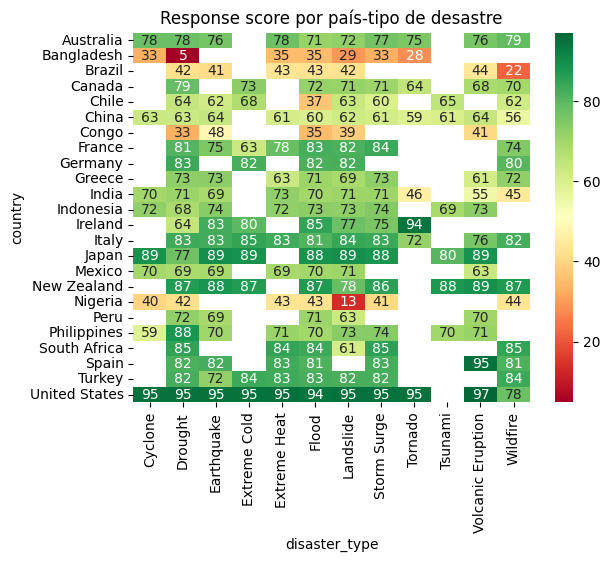

In [27]:
pivot = df.pivot_table('response_score', 'country', 'disaster_type', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn')
plt.title('Response score por país-tipo de desastre')
plt.show();

En cuanto al índice de respuesta se infiere que, aunque los países con mejores y peores calificaciones coinciden con los menores y mayores días de recuperación, sí hay algo de variación por tipo de desastre dentro del mismo país. Por ejemplo, Bangladesh responde muy mal a sequías, Nigeria a deslizamientos de tierra y Brasil a incendios, pero algo mejor a otros.

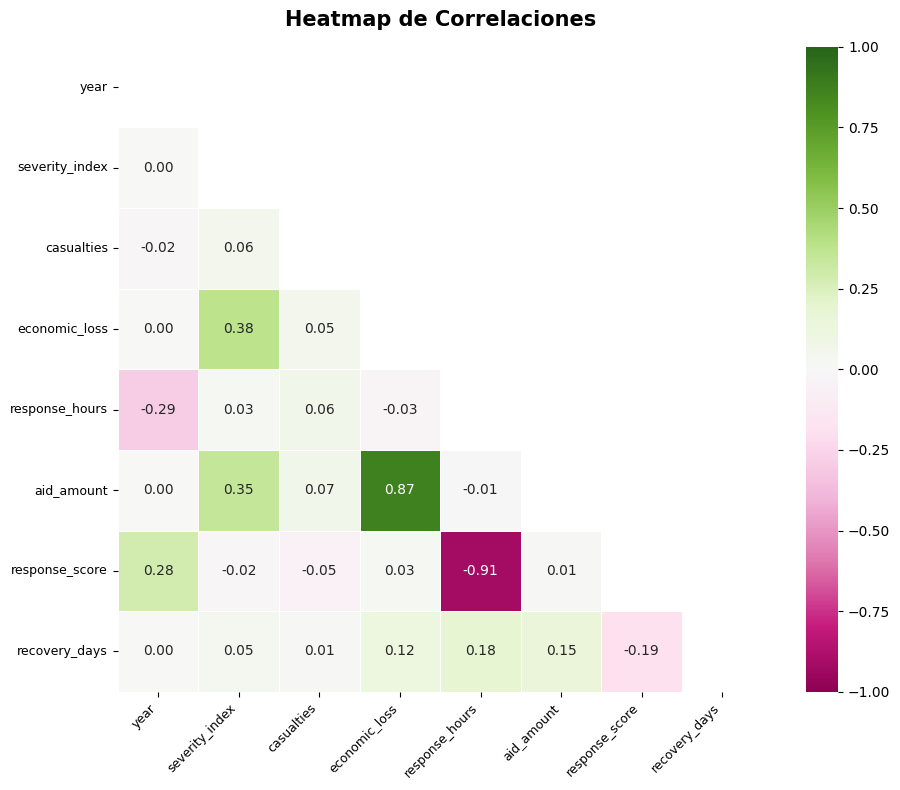

In [28]:
corr_matrix = df[columnas_numericas].corr()

# Máscara para el triángulo superior (evita duplicados)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="PiYG",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title("Heatmap de Correlaciones", fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show();

Como es de esperar, response_score está estrechamente relacionada con response_hours: cuanto más horas se tarda en responder, menor es el score que recibes en la respuesta.  
También hay mucha relación entre aid_amount (el dinero que recibes) y economic_loss (el dinero que se ha perdido por el desastre): a más pérdida económica, mayor dinero recibido.

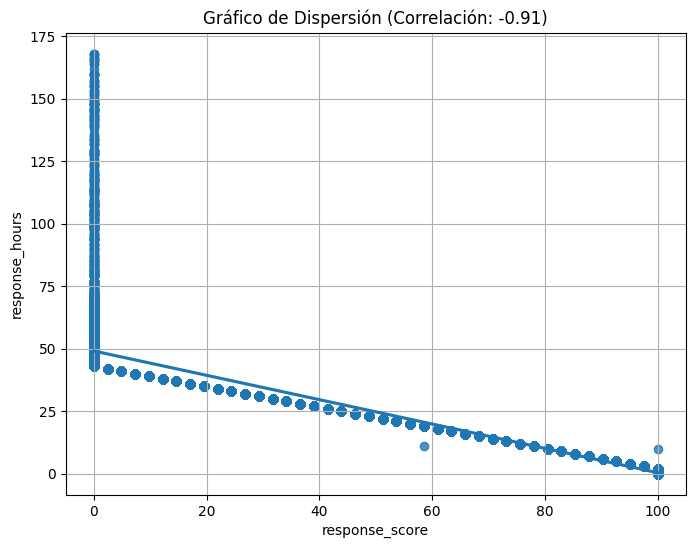

In [29]:
correlacion = df['response_score'].corr(df['response_hours'])

plt.figure(figsize=(8, 6))
sns.regplot(x='response_score', y='response_hours', data=df)
plt.title(f'Gráfico de Dispersión (Correlación: {correlacion:.2f})')
plt.grid(True)
plt.show();

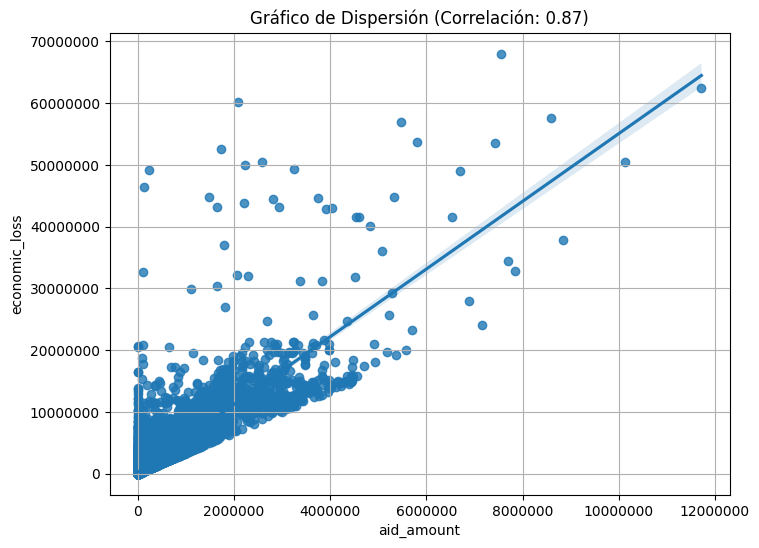

In [45]:
correlacion = df['aid_amount'].corr(df['economic_loss'])

plt.figure(figsize=(8, 6))
sns.regplot(x='aid_amount', y='economic_loss', data=df)
plt.ticklabel_format(style='plain', axis='both')
plt.title(f'Gráfico de Dispersión (Correlación: {correlacion:.2f})')
plt.grid(True)
plt.show();

In [ ]:
# PRE-CLUSTERING
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cogemos las 4 variables
cols_clustering = ['casualties', 'economic_loss', 'response_hours', 'recovery_days']

# 2. Log1p en las que tienen outliers extremos
df_clust = df[cols_clustering].copy()
df_clust['casualties']    = np.log1p(df['casualties'])
df_clust['economic_loss'] = np.log1p(df['economic_loss'])
# df_clust['response_hours'] = np.log1p(df['response_hours']) # --> no tienen distribución normal, pero las mantengo sin el log
# df_clust['recovery_days'] = np.log1p(df['recovery_days'])

# 3. Estandarizamos — PCA es sensible a la escala
X = StandardScaler().fit_transform(df_clust)

# 4. PCA reduce de 4 dimensiones a 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# X_pca tiene shape (49972, 2) — un punto 2D por cada evento

pd.DataFrame(pca.components_, 
             columns=cols_clustering,
             index=['PC1', 'PC2']).round(3)

,casualties,economic_loss,response_hours,recovery_days
PC1,0.665,0.359,0.572,0.318
PC2,-0.056,0.807,-0.553,0.200


C:\Users\cchia\AppData\Local\Temp\ipykernel_26956\1087256561.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_rainbow', len(paises_unicos))


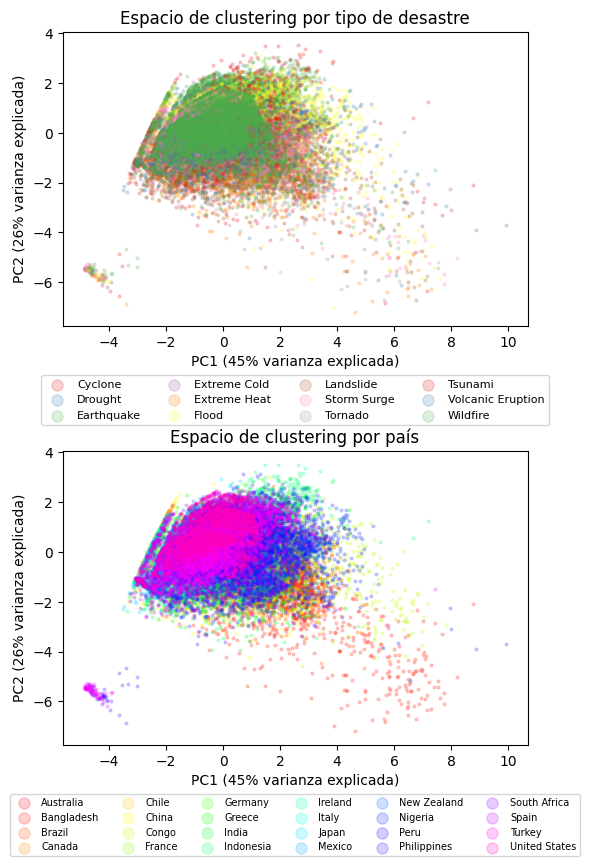

In [ ]:
from matplotlib.colors import to_hex
import matplotlib.cm as cm

fig, axes = plt.subplots(2, 1, figsize=(6, 10))

# --- Por tipo de desastre ---
tipos_unicos = sorted(df['disaster_type'].unique())
palette_tipo = sns.color_palette("Set1", len(tipos_unicos))

for i, tipo in enumerate(tipos_unicos):
    mask = df['disaster_type'].values == tipo
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette_tipo[i], label=tipo,
                    alpha=0.2, s=4)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza explicada)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza explicada)')
axes[0].set_title('Espacio de clustering por tipo de desastre')
axes[0].legend(markerscale=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4)

# --- Por país ---
paises_unicos = sorted(df['country'].unique())
cmap = cm.get_cmap('gist_rainbow', len(paises_unicos))
palette_pais = [to_hex(cmap(i)) for i in range(len(paises_unicos))]

for i, pais in enumerate(paises_unicos):
    mask = df['country'].values == pais
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette_pais[i], label=pais,
                    alpha=0.2, s=4)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza explicada)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza explicada)')
axes[1].set_title('Espacio de clustering por país')
axes[1].legend(markerscale=4, fontsize=7,
               bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=6)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

Este gráfico analiza la viabilidad de hacer una segmentación de eventos por perfil de riesgo y gestión de la respuesta mediante PCA. Las cuatro variables seleccionadas - víctimas, pérdidas económicas, horas de respuesta y días de recuperación - explican conjuntamente el 71% de la varianza total y se distinguen tres zonas diferenciadas: una masa central densa que agrupa la mayoría de eventos, un brazo que se extiende hacia valores altos de PC1, y un grupo reducido pero claramente aislado en la zona inferior izquierda, cuya combinación de valores lo separa notablemente del resto del dataset.  

La coloración por tipo de desastre y por país muestra que ninguna de estas categorías explica por sí sola la posición de los eventos en el espacio: los colores aparecen completamente mezclados en todas las zonas, lo que indica que eventos de distinto tipo y distinto país pueden tener perfiles de impacto y respuesta muy similares.

### FEATURE ENGINEERING

* Tranformaciones logarítmicas (reducir el skewness y mejorar la distribución de las variables)

In [46]:
df_fe = df.copy()

cols_log = ['casualties', 'economic_loss', 'aid_amount', 'recovery_days', 'response_hours'] # variables a transformar

for col in cols_log:
    df_fe[f'{col}_log'] = np.log1p(df_fe[col])

print("Skewness antes y después:")
for col in cols_log:
    antes = df[col].skew()
    despues = df_fe[f'{col}_log'].skew()
    print(f"  {col}: {antes:.2f} → {despues:.2f}")

Skewness antes y después:
  casualties: 157.50 → -0.22
  economic_loss: 8.17 → -0.89
  aid_amount: 7.33 → -0.97
  recovery_days: 3.10 → 0.20
  response_hours: 2.98 → -0.28


* Codificación de variables categóricas

In [47]:
df_fe = pd.get_dummies(df_fe, columns=['country', 'disaster_type'], drop_first=False) # guardo las 24 columnas de países y las 12 de tipos de desastre

In [23]:
# df_fe.to_csv('desastres_y_respuestas_limpio_FE.csv', index=False)

### MODELADO

* Selección de variables

In [48]:
base_dir = os.path.dirname(os.path.abspath("__file__"))
csv_path = os.path.join(base_dir, "data", "desastres_y_respuestas_limpio_FE.csv")
df = pd.read_csv(csv_path)

In [49]:
# Columnas a excluir del objetivo 1 (con severity_index)

excluir_obj1 = [
    'response_score',       
    'response_hours', # leakage   
    'response_hours_log',   
    'casualties', 'economic_loss', 'aid_amount', 'recovery_days' # versiones originales - usamos las log
]

X1 = df.drop(columns=excluir_obj1)
y1 = df['response_score']

In [50]:
# Columnas a excluir del objetivo 1 (sin severity_index)
excluir_obj1 = [
    'response_score',       # target
    'response_hours',       # leakage
    'response_hours_log',   # leakage
    'severity_index',       # leakage
    'casualties', 'economic_loss', 'aid_amount', 'recovery_days' # versiones originales — usamos las log
]

X1_2 = df.drop(columns=excluir_obj1)
y1_2 = df['response_score']

In [51]:
# objetivo 2 (target: recovery_days_log)

excluir_obj2 = [
    'recovery_days',        
    'recovery_days_log',    
    'response_score',       # leakage
    'casualties', 'economic_loss', 'aid_amount', 'response_hours' # versiones originales - usamos las log
]

X2 = df.drop(columns=excluir_obj2)
y2 = df['recovery_days_log']

In [52]:
cols_clust = ['casualties_log', 'economic_loss_log', 
              'response_hours_log', 'recovery_days_log']

X3 = df[cols_clust]

* Train-test split y estandarización

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

X1_2_train, X1_2_test, y1_2_train, y1_2_test = train_test_split(
    X1_2, y1_2, test_size=0.2, random_state=42)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

# X3 no necesita split — clustering usa todos los datos

print(X1_train.shape, X1_test.shape)
print(X1_2_train.shape, X1_2_test.shape)
print(X2_train.shape, X2_test.shape)

(39976, 42) (9994, 42)
(39976, 41) (9994, 41)
(39976, 42) (9994, 42)


In [54]:
scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)  
X1_test_sc  = scaler1.transform(X1_test)     

scaler1_2 = StandardScaler()
X1_2_train_sc = scaler1_2.fit_transform(X1_2_train)  
X1_2_test_sc  = scaler1_2.transform(X1_2_test)   

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

scaler3 = StandardScaler()
X3_sc = scaler3.fit_transform(X3)

### PREDICCIÓN

* Métricas a usar para los objetivos 1 y 2:

MAE (Mean Absolute Error): Calcula la media de las diferencias absolutas entre los valores reales y los predichos. Es fácil de interpretar y no penaliza fuertemente los valores atípicos (outliers).  

RMSE (Root Mean Squared Error): Es la raíz cuadrada del MSE. Ofrece una medida en las mismas unidades que la variable objetivo.  

R^2 Score (Coeficiente de Determinación): Indica qué tan bien se ajusta el modelo a los datos (1 es ajuste perfecto, 0 o negativo es mal ajuste).

#### Objetivo 1 (response_score) - incluyendo "severity-index"

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X1_train_sc, y1_train)

y1_pred_lr = lr.predict(X1_test_sc)
y1_pred_lr_train = lr.predict(X1_train_sc)

print("── Linear Regression ──")
print(f"R²:     {r2_score(y1_test, y1_pred_lr):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_lr_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_lr):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_lr_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_lr):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_lr_train):.4f}")

── Linear Regression ──
R²:     0.7493
R²_t:   0.7468
RMSE:   14.0286
RMSE_t: 13.9852
MAE:    10.5112
MAE_t:  10.5028


In [32]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X1_train_sc, y1_train)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X1_train_sc, y1_train)

enet = ElasticNetCV(alphas=alphas,
                    l1_ratio=[0.1, 0.5, 0.9, 0.95, 1.0],
                    cv=5, max_iter=10000, random_state=42)
enet.fit(X1_train_sc, y1_train)

for nombre, modelo in [("Ridge", ridge), ("Lasso", lasso), ("ElasticNet", enet)]:
    pred_test  = modelo.predict(X1_test_sc)
    pred_train = modelo.predict(X1_train_sc)
    print(f"── {nombre} ──")
    print(f"  alpha óptimo: {modelo.alpha_:.4f}")
    print(f"  R²:     {r2_score(y1_test, pred_test):.4f}")
    print(f"  R²_t:   {r2_score(y1_train, pred_train):.4f}")
    print(f"  RMSE:   {root_mean_squared_error(y1_test, pred_test):.4f}")
    print(f"  RMSE_t: {root_mean_squared_error(y1_train, pred_train):.4f}")
    print(f"  MAE:    {mean_absolute_error(y1_test, pred_test):.4f}")
    print(f"  MAE_t:  {mean_absolute_error(y1_train, pred_train):.4f}")
    print()

── Ridge ──
  alpha óptimo: 8.2864
  R²:     0.7493
  R²_t:   0.7468
  RMSE:   14.0285
  RMSE_t: 13.9852
  MAE:    10.5109
  MAE_t:  10.5027

── Lasso ──
  alpha óptimo: 0.0010
  R²:     0.7493
  R²_t:   0.7468
  RMSE:   14.0286
  RMSE_t: 13.9852
  MAE:    10.5115
  MAE_t:  10.5031

── ElasticNet ──
  alpha óptimo: 0.0010
  R²:     0.7493
  R²_t:   0.7468
  RMSE:   14.0286
  RMSE_t: 13.9852
  MAE:    10.5114
  MAE_t:  10.5031



In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_rf = {
    'n_estimators': [100, 200, 300],       
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X1_train_sc, y1_train)

y1_pred_rf       = rf_search.predict(X1_test_sc)
y1_pred_rf_train = rf_search.predict(X1_train_sc)

print("Mejores hiperparámetros RF:", rf_search.best_params_)
print(f"R²:     {r2_score(y1_test, y1_pred_rf):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_rf_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_rf):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_rf_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_rf):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_rf_train):.4f}")

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}
R²:     0.9904
R²_t:   0.9966
RMSE:   2.7487
RMSE_t: 1.6226
MAE:    1.0851
MAE_t:  0.5625


In [34]:
importances = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X1.columns
).sort_values(ascending=False)

print(importances.head(10))

casualties_log           0.582605
severity_index           0.254761
country_Bangladesh       0.036566
year                     0.027448
country_Nigeria          0.023326
country_Brazil           0.022401
economic_loss_log        0.017630
recovery_days_log        0.010487
aid_amount_log           0.007404
country_United States    0.005482
dtype: float64


casualties_log y severity_index juntas suman el 84% de la importancia, lo que significa que probablemente response_score fue calculada a partir de ellas, o que severity_index ya es una combinación de casualties y otras variables --> decido añadir un un objetivo 1.2 sin severity_index

In [35]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_gbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'max_depth': [3, 4, 5],                 
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0]            
}

gbm = GradientBoostingRegressor(random_state=42)

gbm_search = RandomizedSearchCV(
    gbm,
    param_distributions=param_dist_gbm,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gbm_search.fit(X1_train_sc, y1_train)

y1_pred_gbm       = gbm_search.predict(X1_test_sc)
y1_pred_gbm_train = gbm_search.predict(X1_train_sc)

print("Mejores hiperparámetros GBM:", gbm_search.best_params_)
print(f"R²:     {r2_score(y1_test, y1_pred_gbm):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_gbm_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_gbm):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_gbm_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_gbm):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_gbm_train):.4f}")

Mejores hiperparámetros GBM: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.1}
R²:     0.9921
R²_t:   0.9931
RMSE:   2.4958
RMSE_t: 2.3099
MAE:    1.1360
MAE_t:  1.1039


In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],  
    'reg_alpha': [0, 0.1, 1],            
    'reg_lambda': [1, 5, 10]      
}

xgb = XGBRegressor(random_state=42, n_jobs=-1,
                   tree_method='hist',  
                   eval_metric='rmse')

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X1_train_sc, y1_train)

y1_pred_xgb       = xgb_search.predict(X1_test_sc)
y1_pred_xgb_train = xgb_search.predict(X1_train_sc)

print("Mejores hiperparámetros XGB:", xgb_search.best_params_)
print(f"R²:     {r2_score(y1_test, y1_pred_xgb):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_xgb_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_xgb):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_xgb_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_xgb):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_xgb_train):.4f}")

Mejores hiperparámetros XGB: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
R²:     0.9924
R²_t:   0.9942
RMSE:   2.4454
RMSE_t: 2.1123
MAE:    0.9767
MAE_t:  0.9120


In [37]:
resultados_obj1 = pd.DataFrame({
    'Modelo': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
               'RandomForest', 'GBM', 'XGBoost'],
    'R²': [
        r2_score(y1_test, y1_pred_lr),
        r2_score(y1_test, ridge.predict(X1_test_sc)),
        r2_score(y1_test, lasso.predict(X1_test_sc)),
        r2_score(y1_test, enet.predict(X1_test_sc)),
        r2_score(y1_test, y1_pred_rf),
        r2_score(y1_test, y1_pred_gbm),
        r2_score(y1_test, y1_pred_xgb)
    ],
    'RMSE': [
        root_mean_squared_error(y1_test, y1_pred_lr),
        root_mean_squared_error(y1_test, ridge.predict(X1_test_sc)),
        root_mean_squared_error(y1_test, lasso.predict(X1_test_sc)),
        root_mean_squared_error(y1_test, enet.predict(X1_test_sc)),
        root_mean_squared_error(y1_test, y1_pred_rf),
        root_mean_squared_error(y1_test, y1_pred_gbm),
        root_mean_squared_error(y1_test, y1_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y1_test, y1_pred_lr),
        mean_absolute_error(y1_test, ridge.predict(X1_test_sc)),
        mean_absolute_error(y1_test, lasso.predict(X1_test_sc)),
        mean_absolute_error(y1_test, enet.predict(X1_test_sc)),
        mean_absolute_error(y1_test, y1_pred_rf),
        mean_absolute_error(y1_test, y1_pred_gbm),
        mean_absolute_error(y1_test, y1_pred_xgb)
    ]
}).sort_values('R²', ascending=False)

print(resultados_obj1.to_string(index=False))

          Modelo       R²      RMSE       MAE
         XGBoost 0.992382  2.445409  0.976698
             GBM 0.992065  2.495759  1.135990
    RandomForest 0.990375  2.748684  1.085094
           Ridge 0.749291 14.028523 10.510926
      ElasticNet 0.749288 14.028602 10.511394
LinearRegression 0.749287 14.028622 10.511150
           Lasso 0.749287 14.028634 10.511507


Los mejores parámetros nos los da XGBoost.  

Además, los R² tan altos (>0.99) confirman lo que ya se sospechaba en el EDA: response_score fue generado a partir de las features mediante una fórmula determinista, por lo que las métricas no reflejan poder predictivo real sino que el modelo está aprendiendo esa fórmula.

In [38]:
import pickle, os
os.makedirs('models', exist_ok=True)

# Guardar modelos Objetivo 1 (con severity_index)
with open('models/obj1_lr.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('models/obj1_ridge.pkl', 'wb') as f:
    pickle.dump(ridge, f)

with open('models/obj1_lasso.pkl', 'wb') as f:
    pickle.dump(lasso, f)

with open('models/obj1_enet.pkl', 'wb') as f:
    pickle.dump(enet, f)

with open('models/obj1_rf.pkl', 'wb') as f:
    pickle.dump(rf_search.best_estimator_, f)

with open('models/obj1_gbm.pkl', 'wb') as f:
    pickle.dump(gbm_search.best_estimator_, f)

with open('models/obj1_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_search.best_estimator_, f)

# Guardar también el scaler (necesario para predecir nuevos datos)
with open('models/obj1_scaler.pkl', 'wb') as f:
    pickle.dump(scaler1, f)

print("✓ Modelos Objetivo 1 guardados en /models/")

✓ Modelos Objetivo 1 guardados en /models/


#### Objetivo 1 (response_score) - excluyendo "severity-index"

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X1_2_train_sc, y1_2_train)

y1_pred_lr       = lr.predict(X1_2_test_sc)
y1_pred_lr_train = lr.predict(X1_2_train_sc)

print("── Linear Regression ──")
print(f"R²:     {r2_score(y1_2_test, y1_pred_lr):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_lr_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_lr):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_lr_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_lr):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_lr_train):.4f}")

── Linear Regression ──
R²:     0.6681
R²_t:   0.6600
RMSE:   16.1402
RMSE_t: 16.2075
MAE:    12.1496
MAE_t:  12.2248


In [40]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X1_2_train_sc, y1_2_train)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X1_2_train_sc, y1_2_train)

enet = ElasticNetCV(alphas=alphas,
                    l1_ratio=[0.1, 0.5, 0.9, 0.95, 1.0],
                    cv=5, max_iter=10000, random_state=42)
enet.fit(X1_2_train_sc, y1_2_train)

for nombre, modelo in [("Ridge", ridge), ("Lasso", lasso), ("ElasticNet", enet)]:
    pred_test  = modelo.predict(X1_2_test_sc)
    pred_train = modelo.predict(X1_2_train_sc)
    print(f"── {nombre} ──")
    print(f"  alpha óptimo: {modelo.alpha_:.4f}")
    print(f"  R²:     {r2_score(y1_2_test, pred_test):.4f}")
    print(f"  R²_t:   {r2_score(y1_2_train, pred_train):.4f}")
    print(f"  RMSE:   {root_mean_squared_error(y1_2_test, pred_test):.4f}")
    print(f"  RMSE_t: {root_mean_squared_error(y1_2_train, pred_train):.4f}")
    print(f"  MAE:    {mean_absolute_error(y1_2_test, pred_test):.4f}")
    print(f"  MAE_t:  {mean_absolute_error(y1_2_train, pred_train):.4f}")
    print()

── Ridge ──
  alpha óptimo: 33.9322
  R²:     0.6681
  R²_t:   0.6600
  RMSE:   16.1403
  RMSE_t: 16.2075
  MAE:    12.1496
  MAE_t:  12.2251

── Lasso ──
  alpha óptimo: 0.0054
  R²:     0.6681
  R²_t:   0.6600
  RMSE:   16.1407
  RMSE_t: 16.2075
  MAE:    12.1504
  MAE_t:  12.2255

── ElasticNet ──
  alpha óptimo: 0.0054
  R²:     0.6681
  R²_t:   0.6600
  RMSE:   16.1407
  RMSE_t: 16.2075
  MAE:    12.1504
  MAE_t:  12.2255



In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_rf = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [5, 10, 20, 30],   
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2', 0.5] 
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20, 
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X1_2_train_sc, y1_2_train)

y1_pred_rf       = rf_search.predict(X1_2_test_sc)
y1_pred_rf_train = rf_search.predict(X1_2_train_sc)

print("Mejores hiperparámetros RF:", rf_search.best_params_)
print(f"R²:     {r2_score(y1_2_test, y1_pred_rf):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_rf_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_rf):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_rf_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_rf):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_rf_train):.4f}")

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}
R²:     0.8467
R²_t:   0.9624
RMSE:   10.9691
RMSE_t: 5.3884
MAE:    6.8104
MAE_t:  3.3081


Parece que hay overfit.

In [42]:
importances = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X1_2.columns
).sort_values(ascending=False)

print(importances.head(10))

casualties_log           0.513169
economic_loss_log        0.104693
year                     0.061724
aid_amount_log           0.051391
recovery_days_log        0.041551
country_Bangladesh       0.040210
country_Nigeria          0.037562
country_Brazil           0.035857
country_United States    0.014048
disaster_type_Flood      0.009244
dtype: float64


In [43]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_gbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'max_depth': [3, 4, 5],             
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0]
}

gbm = GradientBoostingRegressor(random_state=42)

gbm_search = RandomizedSearchCV(
    gbm,
    param_distributions=param_dist_gbm,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gbm_search.fit(X1_2_train_sc, y1_2_train)

y1_pred_gbm       = gbm_search.predict(X1_2_test_sc)
y1_pred_gbm_train = gbm_search.predict(X1_2_train_sc)

print("Mejores hiperparámetros GBM:", gbm_search.best_params_)
print(f"R²:     {r2_score(y1_2_test, y1_pred_gbm):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_gbm_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_gbm):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_gbm_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_gbm):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_gbm_train):.4f}")

Mejores hiperparámetros GBM: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.2}
R²:     0.8412
R²_t:   0.8810
RMSE:   11.1659
RMSE_t: 9.5896
MAE:    7.3214
MAE_t:  6.4940


In [44]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0], 
    'reg_alpha': [0, 0.1, 1],         
    'reg_lambda': [1, 5, 10]          
}

xgb = XGBRegressor(random_state=42, n_jobs=-1,
                   tree_method='hist',  
                   eval_metric='rmse')

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X1_2_train_sc, y1_2_train)

y1_pred_xgb       = xgb_search.predict(X1_2_test_sc)
y1_pred_xgb_train = xgb_search.predict(X1_2_train_sc)

print("Mejores hiperparámetros XGB:", xgb_search.best_params_)
print(f"R²:     {r2_score(y1_2_test, y1_pred_xgb):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_xgb_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_xgb):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_xgb_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_xgb):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_xgb_train):.4f}")

Mejores hiperparámetros XGB: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
R²:     0.8515
R²_t:   0.9143
RMSE:   10.7965
RMSE_t: 8.1369
MAE:    6.9606
MAE_t:  5.4787


In [45]:
resultados_obj1 = pd.DataFrame({
    'Modelo': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
               'RandomForest', 'GBM', 'XGBoost'],
    'R²': [
        r2_score(y1_2_test, y1_pred_lr),
        r2_score(y1_2_test, ridge.predict(X1_2_test_sc)),
        r2_score(y1_2_test, lasso.predict(X1_2_test_sc)),
        r2_score(y1_2_test, enet.predict(X1_2_test_sc)),
        r2_score(y1_2_test, y1_pred_rf),
        r2_score(y1_2_test, y1_pred_gbm),
        r2_score(y1_2_test, y1_pred_xgb)
    ],
    'RMSE': [
        root_mean_squared_error(y1_2_test, y1_pred_lr),
        root_mean_squared_error(y1_2_test, ridge.predict(X1_2_test_sc)),
        root_mean_squared_error(y1_2_test, lasso.predict(X1_2_test_sc)),
        root_mean_squared_error(y1_2_test, enet.predict(X1_2_test_sc)),
        root_mean_squared_error(y1_2_test, y1_pred_rf),
        root_mean_squared_error(y1_2_test, y1_pred_gbm),
        root_mean_squared_error(y1_2_test, y1_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y1_2_test, y1_pred_lr),
        mean_absolute_error(y1_2_test, ridge.predict(X1_2_test_sc)),
        mean_absolute_error(y1_2_test, lasso.predict(X1_2_test_sc)),
        mean_absolute_error(y1_2_test, enet.predict(X1_2_test_sc)),
        mean_absolute_error(y1_2_test, y1_pred_rf),
        mean_absolute_error(y1_2_test, y1_pred_gbm),
        mean_absolute_error(y1_2_test, y1_pred_xgb),
    ]
}).sort_values('R²', ascending=False)

print(resultados_obj1.to_string(index=False))

          Modelo       R²      RMSE       MAE
         XGBoost 0.851505 10.796492  6.960620
    RandomForest 0.846718 10.969115  6.810396
             GBM 0.841169 11.165901  7.321383
LinearRegression 0.668132 16.140209 12.149566
           Ridge 0.668128 16.140308 12.149629
           Lasso 0.668113 16.140675 12.150406
      ElasticNet 0.668113 16.140675 12.150406


Al eliminar severity_index, el R² de XGBoost cae de 0.992 a 0.852, y el RMSE sube de 2.4 a 10.8 puntos. Esto confirma el leakage: severity_index era una de las features con las que se calculó response_score. Asimismo, parece que hay un poco más de overfit en estos casos.  

XGBoost sigue siendo el más equilibrado.  

En cuanto al RMSE, 10 puntos en una escala de 0 a 100 es aceptable para los datos del dataset, pero es un valor alto en la realidad.

In [46]:
with open('models/obj1_2_lr.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('models/obj1_2_ridge.pkl', 'wb') as f:
    pickle.dump(ridge, f)

with open('models/obj1_2_lasso.pkl', 'wb') as f:
    pickle.dump(lasso, f)

with open('models/obj1_2_enet.pkl', 'wb') as f:
    pickle.dump(enet, f)

with open('models/obj1_2_rf.pkl', 'wb') as f:
    pickle.dump(rf_search.best_estimator_, f)

with open('models/obj1_2_gbm.pkl', 'wb') as f:
    pickle.dump(gbm_search.best_estimator_, f)

with open('models/obj1_2_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_search.best_estimator_, f)

with open('models/obj1_2_scaler.pkl', 'wb') as f:
    pickle.dump(scaler1_2, f)

print("✓ Modelos Objetivo 1.2 guardados en /models/")

✓ Modelos Objetivo 1.2 guardados en /models/


#### Objetivo 2 (recovery_days_log)

In [47]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Linear Regression
lr2 = LinearRegression()
lr2.fit(X2_train_sc, y2_train)

y2_pred_lr_log       = lr2.predict(X2_test_sc)
y2_pred_lr_train_log = lr2.predict(X2_train_sc)
y2_pred_lr       = np.expm1(y2_pred_lr_log)
y2_pred_lr_train = np.expm1(y2_pred_lr_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("── Linear Regression ──")
print(f"R² (log):     {r2_score(y2_test, y2_pred_lr_log):.4f}")
print(f"R²_t (log):   {r2_score(y2_train, y2_pred_lr_train_log):.4f}")
print(f"RMSE (días):  {root_mean_squared_error(y2_test_real, y2_pred_lr):.4f}")
print(f"RMSE_t(días): {root_mean_squared_error(y2_train_real, y2_pred_lr_train):.4f}")
print(f"MAE (días):   {mean_absolute_error(y2_test_real, y2_pred_lr):.4f}")
print(f"MAE_t (días): {mean_absolute_error(y2_train_real, y2_pred_lr_train):.4f}")

# Ridge
alphas = np.logspace(-3, 3, 50)

ridge2 = RidgeCV(alphas=alphas, cv=5)
ridge2.fit(X2_train_sc, y2_train)

# Lasso
lasso2 = LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=42)
lasso2.fit(X2_train_sc, y2_train)

# ElasticNet
enet2 = ElasticNetCV(alphas=alphas,
                     l1_ratio=[0.1, 0.5, 0.9, 0.95, 1.0],
                     cv=5, max_iter=5000, random_state=42)
enet2.fit(X2_train_sc, y2_train)

for nombre, modelo in [("Ridge", ridge2), ("Lasso", lasso2), ("ElasticNet", enet2)]:
    pred_test_log  = modelo.predict(X2_test_sc)
    pred_train_log = modelo.predict(X2_train_sc)
    pred_test      = np.expm1(pred_test_log)
    pred_train     = np.expm1(pred_train_log)
    print(f"── {nombre} ──")
    print(f"alpha óptimo: {modelo.alpha_:.4f}")
    print(f"R²:     {r2_score(y2_test, pred_test_log):.4f}")
    print(f"R²_t:   {r2_score(y2_train, pred_train_log):.4f}")
    print(f"RMSE:   {root_mean_squared_error(y2_test_real, pred_test):.4f}")
    print(f"RMSE_t: {root_mean_squared_error(y2_train_real, pred_train):.4f}")
    print(f"MAE:    {mean_absolute_error(y2_test_real, pred_test):.4f}")
    print(f"MAE_t:  {mean_absolute_error(y2_train_real, pred_train):.4f}")
    print()

── Linear Regression ──
R² (log):     0.6948
R²_t (log):   0.6946
RMSE (días):  115.1768
RMSE_t(días): 122.0425
MAE (días):   53.1038
MAE_t (días): 55.8565
── Ridge ──
alpha óptimo: 14.5635
R²:     0.6948
R²_t:   0.6946
RMSE:   115.2031
RMSE_t: 122.0725
MAE:    53.1081
MAE_t:  55.8632

── Lasso ──
alpha óptimo: 0.0010
R²:     0.6948
R²_t:   0.6946
RMSE:   115.5695
RMSE_t: 122.4556
MAE:    53.1672
MAE_t:  55.9384

── ElasticNet ──
alpha óptimo: 0.0010
R²:     0.6948
R²_t:   0.6946
RMSE:   115.2841
RMSE_t: 122.1592
MAE:    53.1217
MAE_t:  55.8821



In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_rf2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf2 = RandomForestRegressor(random_state=42, n_jobs=-1)

rf2_search = RandomizedSearchCV(
    rf2,
    param_distributions=param_dist_rf2,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf2_search.fit(X2_train_sc, y2_train)

y2_pred_rf_log       = rf2_search.predict(X2_test_sc)
y2_pred_rf_train_log = rf2_search.predict(X2_train_sc)
y2_pred_rf           = np.expm1(y2_pred_rf_log)
y2_pred_rf_train     = np.expm1(y2_pred_rf_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("Mejores hiperparámetros RF:", rf2_search.best_params_)
print(f"R²:     {r2_score(y2_test, y2_pred_rf_log):.4f}")
print(f"R²_t:   {r2_score(y2_train, y2_pred_rf_train_log):.4f}")
print(f"RMSE:   {root_mean_squared_error(y2_test_real, y2_pred_rf):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y2_train_real, y2_pred_rf_train):.4f}")
print(f"MAE:    {mean_absolute_error(y2_test_real, y2_pred_rf):.4f}")
print(f"MAE_t:  {mean_absolute_error(y2_train_real, y2_pred_rf_train):.4f}")

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}
R²:     0.7808
R²_t:   0.8426
RMSE:   89.0248
RMSE_t: 78.9894
MAE:    43.5144
MAE_t:  38.2963


Parece que hay algo de overfit.

In [49]:
importances = pd.Series(
    rf2_search.best_estimator_.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

print(importances.head(10))

country_Japan                 0.096022
country_Nigeria               0.076061
disaster_type_Extreme Heat    0.058190
country_Congo                 0.056582
country_Australia             0.054063
country_United States         0.051158
country_South Africa          0.049523
country_Canada                0.047929
aid_amount_log                0.039848
country_Indonesia             0.035875
dtype: float64


In [50]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_gbm2 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0]
}

gbm2 = GradientBoostingRegressor(random_state=42)

gbm2_search = RandomizedSearchCV(
    gbm2,
    param_distributions=param_dist_gbm2,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gbm2_search.fit(X2_train_sc, y2_train)

y2_pred_gbm_log       = gbm2_search.predict(X2_test_sc)
y2_pred_gbm_train_log = gbm2_search.predict(X2_train_sc)
y2_pred_gbm           = np.expm1(y2_pred_gbm_log)
y2_pred_gbm_train     = np.expm1(y2_pred_gbm_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("Mejores hiperparámetros GBM:", gbm2_search.best_params_)
print(f"R²:     {r2_score(y2_test, y2_pred_gbm_log):.4f}")
print(f"R²_t:   {r2_score(y2_train, y2_pred_gbm_train_log):.4f}")
print(f"RMSE:   {root_mean_squared_error(y2_test_real, y2_pred_gbm):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y2_train_real, y2_pred_gbm_train):.4f}")
print(f"MAE:    {mean_absolute_error(y2_test_real, y2_pred_gbm):.4f}")
print(f"MAE_t:  {mean_absolute_error(y2_train_real, y2_pred_gbm_train):.4f}")

Mejores hiperparámetros GBM: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': 3, 'learning_rate': 0.2}
R²:     0.7857
R²_t:   0.7899
RMSE:   84.1829
RMSE_t: 86.8425
MAE:    42.5303
MAE_t:  43.9433


In [51]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_xgb2 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

xgb2 = XGBRegressor(random_state=42, n_jobs=-1,
                    tree_method='hist',
                    eval_metric='rmse')

xgb2_search = RandomizedSearchCV(
    xgb2,
    param_distributions=param_dist_xgb2,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb2_search.fit(X2_train_sc, y2_train)

y2_pred_xgb_log       = xgb2_search.predict(X2_test_sc)
y2_pred_xgb_train_log = xgb2_search.predict(X2_train_sc)
y2_pred_xgb           = np.expm1(y2_pred_xgb_log)
y2_pred_xgb_train     = np.expm1(y2_pred_xgb_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("Mejores hiperparámetros XGB:", xgb2_search.best_params_)
print(f"R²:     {r2_score(y2_test, y2_pred_xgb_log):.4f}")
print(f"R²_t:   {r2_score(y2_train, y2_pred_xgb_train_log):.4f}")
print(f"RMSE:   {root_mean_squared_error(y2_test_real, y2_pred_xgb):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y2_train_real, y2_pred_xgb_train):.4f}")
print(f"MAE:    {mean_absolute_error(y2_test_real, y2_pred_xgb):.4f}")
print(f"MAE_t:  {mean_absolute_error(y2_train_real, y2_pred_xgb_train):.4f}")

Mejores hiperparámetros XGB: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
R²:     0.7870
R²_t:   0.7968
RMSE:   84.2576
RMSE_t: 84.3672
MAE:    42.3829
MAE_t:  42.9383


In [52]:
resultados_obj2 = pd.DataFrame({
    'Modelo': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
               'RandomForest', 'GBM', 'XGBoost'],
    'R² (log)': [
        r2_score(y2_test, y2_pred_lr_log),
        r2_score(y2_test, ridge2.predict(X2_test_sc)),
        r2_score(y2_test, lasso2.predict(X2_test_sc)),
        r2_score(y2_test, enet2.predict(X2_test_sc)),
        r2_score(y2_test, y2_pred_rf_log),
        r2_score(y2_test, y2_pred_gbm_log),
        r2_score(y2_test, y2_pred_xgb_log)
    ],
    'RMSE (días)': [
        root_mean_squared_error(y2_test_real, y2_pred_lr),
        root_mean_squared_error(y2_test_real, np.expm1(ridge2.predict(X2_test_sc))),
        root_mean_squared_error(y2_test_real, np.expm1(lasso2.predict(X2_test_sc))),
        root_mean_squared_error(y2_test_real, np.expm1(enet2.predict(X2_test_sc))),
        root_mean_squared_error(y2_test_real, y2_pred_rf),
        root_mean_squared_error(y2_test_real, y2_pred_gbm),
        root_mean_squared_error(y2_test_real, y2_pred_xgb)
    ],
    'MAE (días)': [
        mean_absolute_error(y2_test_real, y2_pred_lr),
        mean_absolute_error(y2_test_real, np.expm1(ridge2.predict(X2_test_sc))),
        mean_absolute_error(y2_test_real, np.expm1(lasso2.predict(X2_test_sc))),
        mean_absolute_error(y2_test_real, np.expm1(enet2.predict(X2_test_sc))),
        mean_absolute_error(y2_test_real, y2_pred_rf),
        mean_absolute_error(y2_test_real, y2_pred_gbm),
        mean_absolute_error(y2_test_real, y2_pred_xgb)
    ]
}).sort_values('R² (log)', ascending=False)

print(resultados_obj2.to_string(index=False))

          Modelo  R² (log)  RMSE (días)  MAE (días)
         XGBoost  0.786978    84.257597   42.382921
             GBM  0.785663    84.182923   42.530276
    RandomForest  0.780763    89.024764   43.514417
           Lasso  0.694794   115.569513   53.167240
      ElasticNet  0.694781   115.284092   53.121747
           Ridge  0.694763   115.203126   53.108126
LinearRegression  0.694751   115.176844   53.103818


Los mejores parámetros, sin pinta de overfit, nos los da XGBoost.

RMSE de 84 días es mucho, porque significa que el modelo se equivoca en media casi 3 meses al predecir cuánto tarda un país en recuperarse. En este sentido, hay dos lecturas posibles:
- La optimista: predecir recovery_days es inherentemente difícil porque depende de factores que no están en el dataset (tales como gobernanza, infraestructura, ayuda internacional concreta...), y un R² de 0.79 con variables tan generales no está mal.  
- La pesimista: el dataset es sintético y, si recovery_days se generó con algo de ruido aleatorio grande, el modelo nunca podrá capturarlo del todo.

In [53]:
with open('models/obj2_lr.pkl', 'wb') as f:
    pickle.dump(lr2, f)

with open('models/obj2_ridge.pkl', 'wb') as f:
    pickle.dump(ridge2, f)

with open('models/obj2_lasso.pkl', 'wb') as f:
    pickle.dump(lasso2, f)

with open('models/obj2_enet.pkl', 'wb') as f:
    pickle.dump(enet2, f)

with open('models/obj2_rf.pkl', 'wb') as f:
    pickle.dump(rf2_search.best_estimator_, f)

with open('models/obj2_gbm.pkl', 'wb') as f:
    pickle.dump(gbm2_search.best_estimator_, f)

with open('models/obj2_xgb.pkl', 'wb') as f:
    pickle.dump(xgb2_search.best_estimator_, f)

with open('models/obj2_scaler.pkl', 'wb') as f:
    pickle.dump(scaler2, f)

print("✓ Modelos Objetivo 2 guardados en /models/")

✓ Modelos Objetivo 2 guardados en /models/


#### Objetivo 3 (clustering)

* KMeans

In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

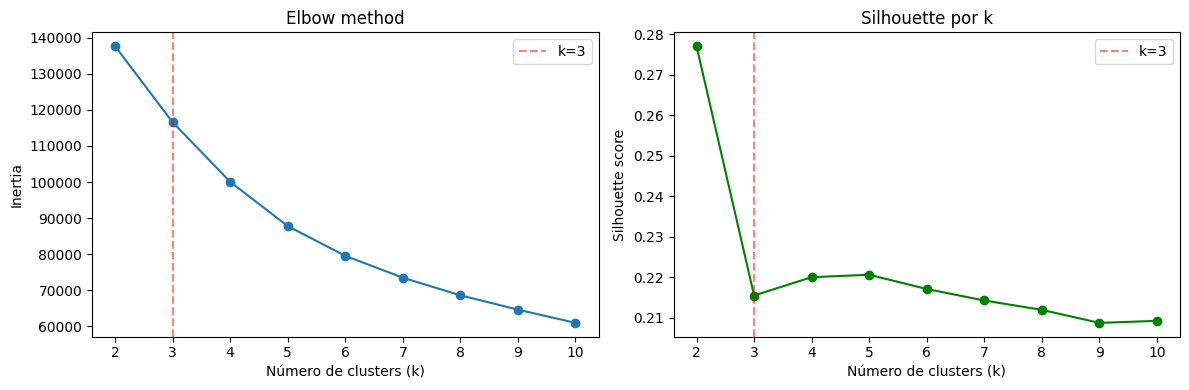


Silhouette scores:
  k=2: 0.2770
  k=3: 0.2155
  k=4: 0.2200
  k=5: 0.2206
  k=6: 0.2171
  k=7: 0.2143
  k=8: 0.2120
  k=9: 0.2088
  k=10: 0.2093


In [55]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X3_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X3_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3') # esto es porque en el EDA vi tres grupos diferenciados
axes[0].legend()

axes[1].plot(K_range, silhouettes, marker='o', color='green')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette por k')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
axes[1].legend()

plt.tight_layout()
plt.show();

print("\nSilhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

No hay un elbow muy marcado y el mejor Silhouette score lo tiene k=2. Los Silhouette score de k=3 a k=6 son super parecidos. Opto por continuar con k=2 y k=3 para ver qué sale.

In [56]:
for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    df[f'cluster_k{k}'] = km.fit_predict(X3_sc)
    perfil = np.expm1(df.groupby(f'cluster_k{k}')[cols_clust].mean()) # lo pasamos a exponencial
    print(f"\n── Perfil medio k={k} (escala real) ──")
    print(perfil.round(1))


── Perfil medio k=2 (escala real) ──
            casualties_log  economic_loss_log  response_hours_log  \
cluster_k2                                                          
0                     45.9           516716.5                19.0   
1                      6.3           175724.5                 5.2   

            recovery_days_log  
cluster_k2                     
0                       108.5  
1                        50.7  

── Perfil medio k=3 (escala real) ──
            casualties_log  economic_loss_log  response_hours_log  \
cluster_k3                                                          
0                      3.8            96787.3                 4.6   
1                     49.9           490480.5                21.1   
2                     22.6           539946.0                 9.7   

            recovery_days_log  
cluster_k3                     
0                        70.6  
1                       168.6  
2                        31.8  


k=2 --> dos grupos: uno con muchas muertes, altas pérdidas económicas, muchas horas de respuesta y muchos días de recuperación; otro con pocas muertes, pérdida económica tirando a baja, pocas horas de respuesta y días de respuesta tirando a bajo.  

k=3 --> tres grupos: uno con impacto mínimo y gestión rápida, otro con alto impacto y mala gestión (el grupo problemático) y otro con impacto medio y recuperación muy rápida (interesante: pérdida económica alta pero se recuperan rápido)

Decido continuar con k=3.

In [58]:
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, n_init=10, random_state=42) 
df['cluster'] = kmeans.fit_predict(X3_sc)

print(f"Silhouette score final (k={k_optimo}): {silhouette_score(X3_sc, df['cluster']):.4f}")
print("\nDistribución de clusters:")
print(df['cluster'].value_counts().sort_index())

Silhouette score final (k=3): 0.2155

Distribución de clusters:
cluster
0    14704
1    19131
2    16135
Name: count, dtype: int64


Los tres clusters están bastante equilibrados. El Silhouette score es bajo, pero probablemente se debe a que los datos son sintéticos y las variables de clustering se generaron con distribuciones solapadas.

In [59]:
# Medias en escala original (no escalada) para interpretar
perfil = df.groupby('cluster')[['casualties_log', 'economic_loss_log',
                                 'response_hours_log', 'recovery_days_log']].mean()

# También en escala real (deshacer el log)
perfil_real = np.expm1(perfil)
perfil_real.columns = ['víctimas', 'pérdida_económica', 'horas_respuesta', 'días_recuperación']

print("Perfil medio por cluster (escala real):")
print(perfil_real.round(1))

Perfil medio por cluster (escala real):
         víctimas  pérdida_económica  horas_respuesta  días_recuperación
cluster                                                                 
0             3.8            96787.3              4.6               70.6
1            49.9           490480.5             21.1              168.6
2            22.6           539946.0              9.7               31.8


Varianza explicada: PC1=48.0%, PC2=25.3%, Total=73.3%


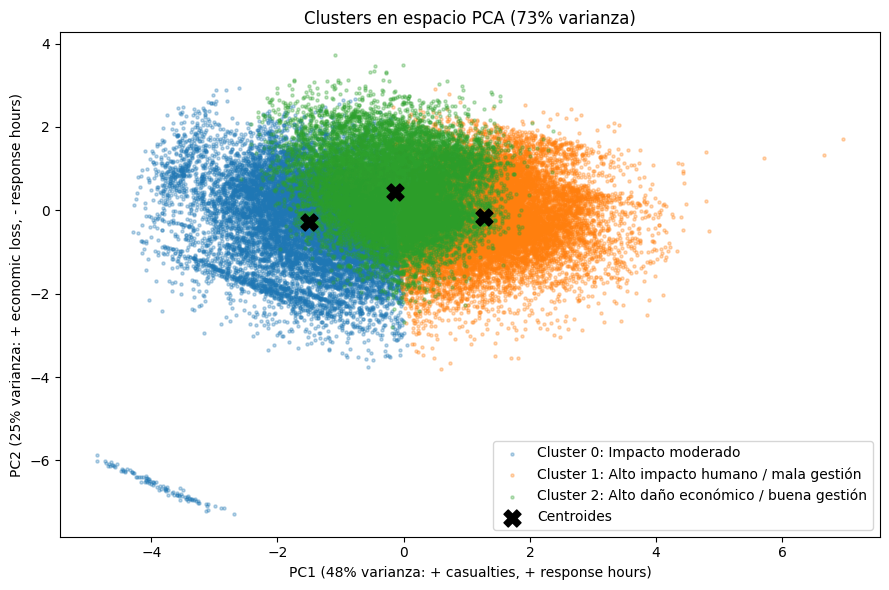

In [63]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3_sc)

print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")

colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
nombres_cluster = {0: 'Cluster 0: Impacto moderado', 1: 'Cluster 1: Alto impacto humano / mala gestión', 2: 'Cluster 2: Alto daño económico / buena gestión'}

fig, ax = plt.subplots(figsize=(9, 6))

for c in range(k_optimo):
    mask = df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colores[c], label=nombres_cluster[c],
               alpha=0.3, s=5)

# Centroides en el espacio PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza: + casualties, + response hours)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza: + economic loss, - response hours)')
ax.set_title('Clusters en espacio PCA (73% varianza)')
ax.legend()
plt.tight_layout()
plt.show();

Hay mucho solapamiento entre nubes, especialmente entre naranja y verde en el centro; los bordes entre clusters son difusos, no hay separación limpia.  

Distribución por tipo de desastre (% por fila):
disaster_type  Cyclone  Drought  Earthquake  Extreme Cold  Extreme Heat  \
cluster                                                                   
0                 0.05     0.09        0.09          0.05          0.11   
1                 0.04     0.13        0.13          0.00          0.07   
2                 0.09     0.09        0.13          0.05          0.14   

disaster_type  Flood  Landslide  Storm Surge  Tornado  Tsunami  \
cluster                                                          
0               0.14       0.18         0.11     0.02     0.02   
1               0.19       0.16         0.11     0.01     0.04   
2               0.13       0.09         0.08     0.02     0.01   

disaster_type  Volcanic Eruption  Wildfire  
cluster                                     
0                           0.04      0.10  
1                           0.03      0.07  
2                           0.03      0.13  

Distribución por pa

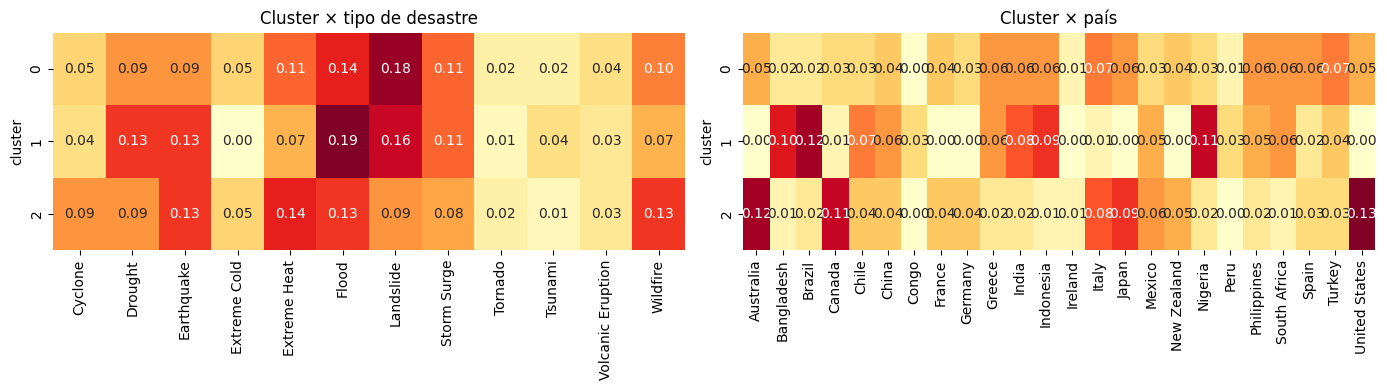

In [60]:
# Reconstruir disaster_type y country desde las dummies
disaster_cols = [c for c in df.columns if c.startswith('disaster_type_')]
country_cols  = [c for c in df.columns if c.startswith('country_')]

df['disaster_type'] = df[disaster_cols].idxmax(axis=1).str.replace('disaster_type_', '')
df['country']       = df[country_cols].idxmax(axis=1).str.replace('country_', '')

# Cluster × tipo de desastre
ct_tipo = pd.crosstab(df['cluster'], df['disaster_type'], normalize='index').round(2)
print("Distribución por tipo de desastre (% por fila):")
print(ct_tipo)

print()

# Cluster × país (top 8 países más frecuentes para no saturar)
top_paises = df['country'].value_counts().head(8).index
ct_pais = pd.crosstab(df[df['country'].isin(top_paises)]['cluster'],
                       df[df['country'].isin(top_paises)]['country'],
                       normalize='index').round(2)
print("Distribución por país — top 8 (% por fila):")
print(ct_pais)

print()

# Heatmap visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ct_tipo, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], cbar=False)
axes[0].set_title('Cluster × tipo de desastre')
axes[0].set_xlabel('')

sns.heatmap(pd.crosstab(df['cluster'], df['country'], normalize='index').round(2),
            annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], cbar=False)
axes[1].set_title('Cluster × país')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

KMeans con k=3 es el modelo final por ser el más interpretable. El Silhouette Score es bajo pero esperable dado el solapamiento inherente del dataset sintético. Los 3 clusters se interpretan mediante PCA (71% de varianza explicada):  
- PC1 (45% varianza): carga principalmente en casualties (+0.665) y response_hours (+0.572). Es el eje de impacto humano y gestión deficiente. Valores altos de PC1 = muchas víctimas y respuesta lenta.
- PC2 (26% varianza): carga positiva en economic_loss (+0.807) y negativa en response_hours (−0.553). Es el eje de contraste económico vs. operacional. PC2 alto = daño económico elevado pero respuesta rápida.

Los tres clusters resultantes son: 
- Cluster 0 — Impacto moderado (mediana: 44 víctimas, 550k€ pérdida, 18h respuesta, 81 días recuperación)
- Cluster 1 — Alto impacto / Recuperación muy lenta (40 víctimas, 800k€, 19h, 668 días - PC1 alto, concentrado en Congo, Nigeria, Indonesia)
- Cluster 2 — Respuesta eficiente (7 víctimas, 160k€, 8h, 54 días - PC2 alto, países desarrollados)

In [62]:
with open('models/obj3_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

* DBSCAN

In [64]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

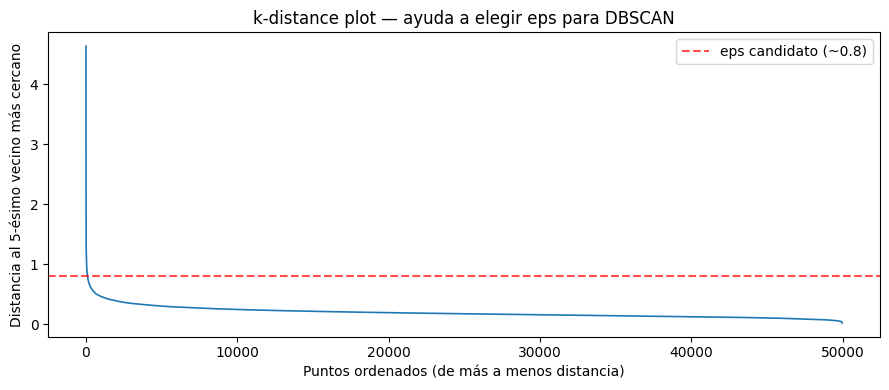

In [65]:
min_samples = 5  # valor de partida estándar para datasets medianos

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X3_sc)
distancias, _ = nn.kneighbors(X3_sc)

# La columna -1 es la distancia al vecino más lejano de los min_samples
k_distancias = np.sort(distancias[:, -1])[::-1]  # orden descendente

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distancias, linewidth=1.2)
ax.set_xlabel('Puntos ordenados (de más a menos distancia)')
ax.set_ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
ax.set_title('k-distance plot — ayuda a elegir eps para DBSCAN')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='eps candidato (~0.8)')
ax.legend()
plt.tight_layout()
plt.show();

In [66]:
eps_valores      = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]
min_samples_vals = [3, 5, 7, 10]

resultados_dbscan = []

for eps in eps_valores:
    for ms in min_samples_vals:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X3_sc)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido    = (labels == -1).sum()
        pct_ruido  = n_ruido / len(labels) * 100
        
        # Silhouette solo tiene sentido con ≥2 clusters y al menos
        # un punto no-ruido. Si no se cumple, guardamos NaN.
        if n_clusters >= 2 and (labels != -1).sum() > 0:
            # silhouette_score solo evalúa puntos con label != -1
            mask_no_ruido = labels != -1
            sil = silhouette_score(X3_sc[mask_no_ruido], labels[mask_no_ruido])
        else:
            sil = np.nan
        
        resultados_dbscan.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'pct_ruido': round(pct_ruido, 1),
            'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan
        })

df_res = pd.DataFrame(resultados_dbscan)

# Filtrar candidatos razonables: ≥2 clusters, ruido <25%
candidatos = df_res[
    (df_res['n_clusters'] >= 2) &
    (df_res['pct_ruido'] < 25)
].sort_values('silhouette', ascending=False)

print("── Mejores combinaciones eps × min_samples ──")
print(candidatos.head(10).to_string(index=False))

── Mejores combinaciones eps × min_samples ──
 eps  min_samples  n_clusters  pct_ruido  silhouette
 1.0           10           2        0.1      0.6722
 1.2            7           2        0.0      0.6722
 1.2            5           2        0.0      0.6722
 1.2            3           2        0.0      0.6722
 1.0            5           2        0.1      0.6721
 0.9            5           2        0.1      0.6721
 0.9           10           2        0.1      0.6721
 0.9            7           2        0.1      0.6721
 1.0            7           2        0.1      0.6721
 1.2           10           2        0.0      0.6721


In [67]:
eps_optimo = 0.8   # ← ajusta según el codo de tu k-distance plot
ms_optimo  = 5     # ← ajusta según la tabla de candidatos

dbscan = DBSCAN(eps=eps_optimo, min_samples=ms_optimo)
df['cluster_dbscan'] = dbscan.fit_predict(X3_sc)

n_clusters_final = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_ruido_final    = (df['cluster_dbscan'] == -1).sum()

print(f"\n── DBSCAN con eps={eps_optimo}, min_samples={ms_optimo} ──")
print(f"Clusters encontrados: {n_clusters_final}")
print(f"Puntos de ruido:      {n_ruido_final} ({n_ruido_final/len(df)*100:.1f}%)")
print(f"\nDistribución:\n{df['cluster_dbscan'].value_counts().sort_index()}")
# El label -1 son los outliers/ruido, no un cluster real.

# Silhouette solo sobre puntos no-ruido
mask_no_ruido = df['cluster_dbscan'] != -1
if n_clusters_final >= 2:
    sil_final = silhouette_score(X3_sc[mask_no_ruido], df['cluster_dbscan'][mask_no_ruido])
    print(f"\nSilhouette score (sin ruido): {sil_final:.4f}")
else:
    print("\nMenos de 2 clusters — ajusta eps o min_samples.")


── DBSCAN con eps=0.8, min_samples=5 ──
Clusters encontrados: 4
Puntos de ruido:      42 (0.1%)

Distribución:
cluster_dbscan
-1       42
 0    49269
 1      553
 2        7
 3       99
Name: count, dtype: int64

Silhouette score (sin ruido): 0.2843



Varianza explicada: PC1=48.0%, PC2=25.3%, Total=73.3%


C:\Users\cchia\AppData\Local\Temp\ipykernel_26956\2161852849.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', n_clusters_final)


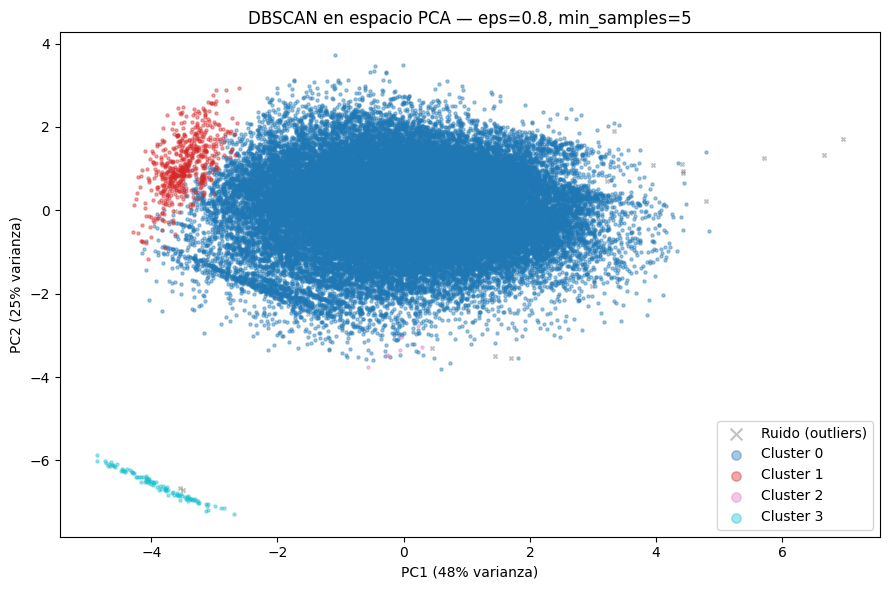

In [68]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3_sc)

print(f"\nVarianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")

labels_dbscan = df['cluster_dbscan'].values
cluster_ids   = sorted(set(labels_dbscan))

# Paleta: ruido en gris, clusters en colores
cmap    = plt.cm.get_cmap('tab10', n_clusters_final)
colores = {cid: cmap(i) for i, cid in enumerate(c for c in cluster_ids if c != -1)}
colores[-1] = (0.4, 0.4, 0.4, 0.5)  # gris semitransparente para ruido

fig, ax = plt.subplots(figsize=(9, 6))

for cid in cluster_ids:
    mask = labels_dbscan == cid
    nombre = f'Cluster {cid}' if cid != -1 else 'Ruido (outliers)'
    marker = 'o' if cid != -1 else 'x'
    size   = 5   if cid != -1 else 8
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colores[cid], label=nombre,
               alpha=0.4, s=size, marker=marker)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza)')
ax.set_title(f'DBSCAN en espacio PCA — eps={eps_optimo}, min_samples={ms_optimo}')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show();

In [69]:
df_sin_ruido = df[df['cluster_dbscan'] != -1].copy()

perfil_dbscan = df_sin_ruido.groupby('cluster_dbscan')[cols_clust].mean()
perfil_real   = np.expm1(perfil_dbscan)
perfil_real.columns = ['víctimas', 'pérdida_económica_M$', 'horas_respuesta', 'días_recuperación']

print("── Perfil medio por cluster DBSCAN (escala real) ──")
print(perfil_real.round(1))

── Perfil medio por cluster DBSCAN (escala real) ──
                víctimas  pérdida_económica_M$  horas_respuesta  \
cluster_dbscan                                                    
0                   19.6              322348.3             10.9   
1                    0.0              278668.8              0.0   
2                    1.1                6612.9            113.9   
3                    0.0                   0.0              8.6   

                días_recuperación  
cluster_dbscan                     
0                            76.8  
1                            47.5  
2                           131.1  
3                            93.9  



Distribución por tipo de desastre (% por fila):
disaster_type   Cyclone  Drought  Earthquake  Extreme Cold  Extreme Heat  \
cluster_dbscan                                                             
0                  0.06     0.11        0.12          0.03          0.10   
1                  0.02     0.09        0.10          0.05          0.09   
2                  0.00     0.00        0.00          0.00          0.14   
3                  0.07     0.06        0.12          0.09          0.09   

disaster_type   Flood  Landslide  Storm Surge  Tornado  Tsunami  \
cluster_dbscan                                                    
0                0.16       0.14         0.10     0.02     0.03   
1                0.24       0.19         0.10     0.01     0.01   
2                0.43       0.14         0.14     0.14     0.00   
3                0.22       0.08         0.15     0.00     0.01   

disaster_type   Volcanic Eruption  Wildfire  
cluster_dbscan                               

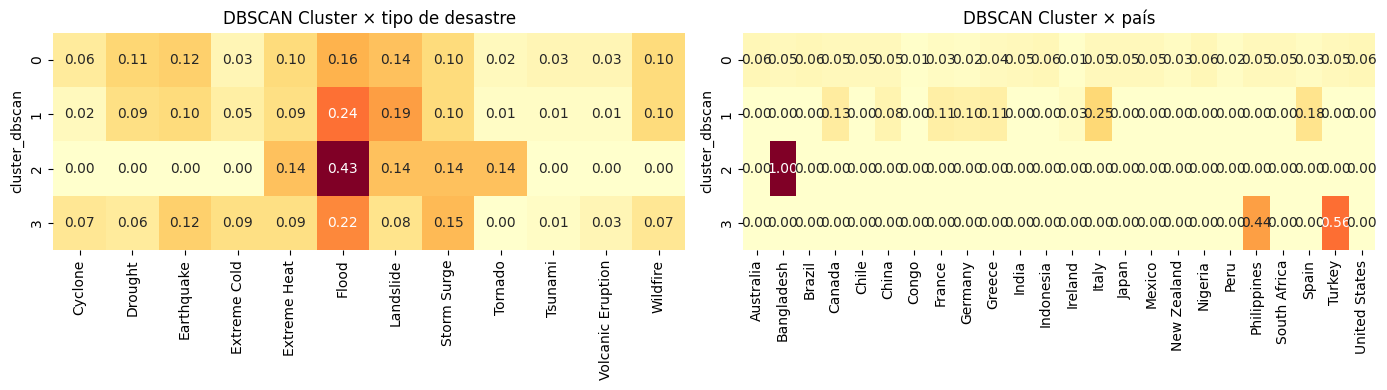

In [70]:
# Reconstruir disaster_type y country desde columnas one-hot en df_sin_ruido
disaster_cols = [c for c in df_sin_ruido.columns if c.startswith('disaster_type_')]
country_cols  = [c for c in df_sin_ruido.columns if c.startswith('country_')]

df_sin_ruido = df_sin_ruido.copy()  # evitar SettingWithCopyWarning
df_sin_ruido['disaster_type'] = (
    df_sin_ruido[disaster_cols]
    .idxmax(axis=1)
    .str.replace('disaster_type_', '', regex=False)
)

df_sin_ruido['country'] = (
    df_sin_ruido[country_cols]
    .idxmax(axis=1)
    .str.replace('country_', '', regex=False)
)

ct_tipo = pd.crosstab(df_sin_ruido['cluster_dbscan'],
                      df_sin_ruido['disaster_type'],
                      normalize='index').round(2)
print("\nDistribución por tipo de desastre (% por fila):")
print(ct_tipo)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ct_tipo, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], cbar=False)
axes[0].set_title('DBSCAN Cluster × tipo de desastre')
axes[0].set_xlabel('')

ct_pais = pd.crosstab(df_sin_ruido['cluster_dbscan'],
                      df_sin_ruido['country'],
                      normalize='index').round(2)
sns.heatmap(ct_pais, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], cbar=False)
axes[1].set_title('DBSCAN Cluster × país')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show();

* HDBSCAN + UMAP

In [71]:
import umap

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
reducer = umap.UMAP(
    n_neighbors=15,  
    min_dist=0.1,     
    n_components=2, 
    random_state=42
)

X_umap = reducer.fit_transform(X3_sc)

df['umap_1'] = X_umap[:, 0]
df['umap_2'] = X_umap[:, 1]

print(f"Embedding UMAP generado: {X_umap.shape}")
print(f"Rango umap_1: [{X_umap[:, 0].min():.2f}, {X_umap[:, 0].max():.2f}]")
print(f"Rango umap_2: [{X_umap[:, 1].min():.2f}, {X_umap[:, 1].max():.2f}]")

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding UMAP generado: (49970, 2)
Rango umap_1: [-5.16, 18.84]
Rango umap_2: [-11.09, 16.07]


C:\Users\cchia\AppData\Local\Temp\ipykernel_26956\1536010444.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db = plt.cm.get_cmap('tab10', n_clusters_db)


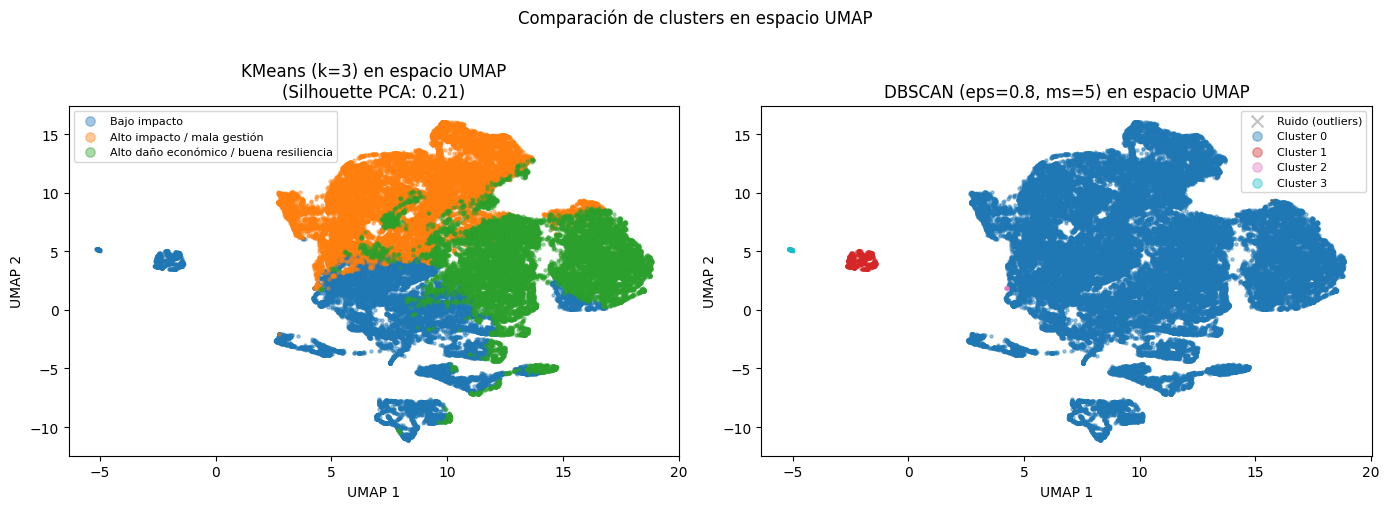

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── KMeans k=3 en UMAP ──
kmeans_col = next(
    (c for c in ['cluster', 'cluster_eda', 'cluster_k3'] if c in df.columns), None
)

nombres_cluster = {
    0: 'Bajo impacto',
    1: 'Alto impacto / mala gestión',
    2: 'Alto daño económico / buena resiliencia'
}
colores_kmeans = ['#1f77b4', '#ff7f0e', '#2ca02c']

for c in sorted(df[kmeans_col].unique()):
    mask = df[kmeans_col] == c
    axes[0].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        color=colores_kmeans[c],
        label=nombres_cluster.get(c, f'Cluster {c}'),
        alpha=0.4, s=5
    )

axes[0].set_title(f'KMeans (k=3) en espacio UMAP\n(Silhouette PCA: 0.21)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(markerscale=3, fontsize=8)

# ── DBSCAN en UMAP ──
labels_dbscan = df['cluster_dbscan'].values
cluster_ids_db = sorted(set(labels_dbscan))
n_clusters_db = len([c for c in cluster_ids_db if c != -1])

cmap_db = plt.cm.get_cmap('tab10', n_clusters_db)
colores_db = {cid: cmap_db(i) for i, cid in enumerate(c for c in cluster_ids_db if c != -1)}
colores_db[-1] = (0.4, 0.4, 0.4, 0.4)  # gris para ruido

for cid in cluster_ids_db:
    mask = labels_dbscan == cid
    nombre = f'Cluster {cid}' if cid != -1 else 'Ruido (outliers)'
    marker = 'o' if cid != -1 else 'x'
    size   = 5   if cid != -1 else 8
    axes[1].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        color=colores_db[cid], label=nombre,
        alpha=0.4, s=size, marker=marker
    )

axes[1].set_title(f'DBSCAN (eps={eps_optimo}, ms={ms_optimo}) en espacio UMAP')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(markerscale=3, fontsize=8)

plt.suptitle('Comparación de clusters en espacio UMAP', fontsize=12, y=1.01)
plt.tight_layout()
plt.show();

In [74]:
sil_umap_kmeans = silhouette_score(X_umap, df[kmeans_col])
print(f"Silhouette KMeans en espacio UMAP:  {sil_umap_kmeans:.4f}")
print(f"Silhouette KMeans en espacio orig.: {silhouette_score(X3_sc, df[kmeans_col]):.4f}")

mask_no_ruido_umap = df['cluster_dbscan'] != -1
if n_clusters_db >= 2:
    sil_umap_dbscan = silhouette_score(
        X_umap[mask_no_ruido_umap],
        df['cluster_dbscan'][mask_no_ruido_umap]
    )
    print(f"\nSilhouette DBSCAN en espacio UMAP:  {sil_umap_dbscan:.4f}")
    print(f"Silhouette DBSCAN en espacio orig.: {silhouette_score(X3_sc[mask_no_ruido_umap], df['cluster_dbscan'][mask_no_ruido_umap]):.4f}")

Silhouette KMeans en espacio UMAP:  0.3208
Silhouette KMeans en espacio orig.: 0.2155

Silhouette DBSCAN en espacio UMAP:  0.0054
Silhouette DBSCAN en espacio orig.: 0.2843


Se han probado otras opciones con HDBScan y UMAP (disponibles en el notebook "Entrenamiento_modelos.ipynb), pero tanto por falta de conocimientos acerca del modelo, como por la interpretabilidad que se pierde, se ha optado por utilizar KMeans y dejar esta alternativa como futuros pasos del proyecto.

In [75]:
with open('models/obj3_dbscan.pkl', 'wb') as f:
    pickle.dump(dbscan, f)

with open('models/obj3_scaler.pkl', 'wb') as f:
    pickle.dump(scaler3, f)

with open('models/obj3_pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print("✓ Modelos Objetivo 3 (clustering) guardados en /models/")

✓ Modelos Objetivo 3 (clustering) guardados en /models/


### CONCLUSIONES Y FUTUROS PASOS

Pese a que el dataset es sintético y estos modelos no son directamente aplicables a casos reales, este trabajo de Machine Learning ofrece posibilidades de predicción que ayudan en la gestión de respuesta de desastres naturales:  
* Por un lado, un análisis en clusters puede ayudar a identificar eventos de alto riesgo con recuperación lenta y anticipar las pérdidas económicas y los países que los concentran, orientando la planificación y asignación de ayuda humanitaria. 
* Asimismo, la previsión de días de recuperación puede apoyar la planificación logística y de recursos a medio plazo tras un desastre, dependiendo del tipo de desastre y el país donde sucede.
* Por último, predecir el índice de respuesta puede proporcionar información sobre los factores asociados a una respuesta ágil y efectiva para detectar brechas de capacidad de respuesta en países vulnerables con puntuaciones sistemáticamente bajas.

Este proyecto demuestra el potencial del Machine Learning en gestión humanitaria, pero está limitado por el uso de datos sintéticos. En consecuencia, sería interesante aplicar predicciones similares con datasets como EM-DAT, OCHA o el Banco Mundial, para que los modelos tengan valor predictivo real. Además, podría ser interesante incluir variables contextuales externas, como el Índice de Desarrollo Humano (IDH), el PIB per cápita o variables relacionadas con gobernanza e infraestructura.  

Del mismo modo, aparte de continuar explorando las posibilidades de HDBScan y UMAP para clustering, se podría realizar un análisis temporal de frecuencia e intensidad de los desastres mediante modelos de series temporales como ARIMA, especialmente en el contexto del cambio climático. 
